In [1]:
from music21 import stream, note, meter, key, clef, dynamics, expressions, layout, tempo, articulations, spanner, bar
from music21 import chord as m21chord
from collections import defaultdict, Counter
import os
import pickle
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random



In [2]:
with open('rhythm_dict/rhythm_dict_with_cleanup_20dec25.pkl', 'rb') as f:
    rhythm_dict = pickle.load(f)

with open('markov_dict/pitch_markov_restrictedG3E6.pkl', 'rb') as f:
    pitch_markov_prob = pickle.load(f)

with open('hand_pattern_dict/hand_patterns_grade1.pkl', 'rb') as f:
    transition_patterns = pickle.load(f)

with open('expressive_dict/expressive_marks_grade1.pkl', 'rb') as f:
    expressive_dict = pickle.load(f)

In [12]:
# ===============================
# GRADE SETTINGS
# ===============================

GRADE_SETTINGS = {
        
    "initial": {
        "structures": [
            {"bars": 4, "time_signature": "4/4"},
            {"bars": 6, "time_signature": "2/4"}
        ],
        "keys": ["C_major", "D_minor"],
        "position": "5_finger"
    },

    1: {

        "structures": [
            {"bars": 4, "time_signature": "4/4"},
            {"bars": 4, "time_signature": "3/4"},
            {"bars": 6, "time_signature": "2/4"}
        ],

        "keys": [
            "C_major",
            "D_minor",
            "G_major",
            "F_major",
            "A_minor"
        ],
        "position": "any_5_finger"
    },


    2: {"structures": [
        {"bars": 4, "time_signature": "4/4"},
        {"bars": 4, "time_signature": "3/4"},
        {"bars": 6, "time_signature": "2/4"},
    ],
    "keys": [
            "C_major",
            "D_minor",
            "G_major",
            "F_major",
            "D_major", 
            "A_minor",
            "E_minor",
            "G_minor" 
        ],
        
    "position": "any_5_finger"

    },

    3: {

    "structures": [
        {"bars": 4, "time_signature": "4/4"},
        {"bars": 4, "time_signature": "3/4"},
        {"bars": 6, "time_signature": "2/4"},
        {"bars": 8, "time_signature": "2/4"},   
        {"bars": 8, "time_signature": "3/4"},   
        {"bars": 4, "time_signature": "3/8"},   
    ],

    "keys": [
        "C_major",
        "G_major",
        "D_major",
        "F_major",
        "B_flat_major",     
        "E_flat_major",     

        "A_minor",
        "D_minor",
        "E_minor",
        "G_minor",
        "B_minor"           
    ],

    
    "position": "extended"

    },

    4: {

    "structures": [
        {"bars": 8, "time_signature": "4/4"},
        #{"bars": 4, "time_signature": "3/4"},
        {"bars": 6, "time_signature": "2/4"},
        {"bars": 8, "time_signature": "2/4"},   
        {"bars": 8, "time_signature": "3/4"},   
        {"bars": 8, "time_signature": "3/8"},
        #{"bars": 4, "time_signature": "6/8"}, #grade4
        {"bars": 8, "time_signature": "6/8"}  #grade4
    ],

    "keys": [
        "C_major",
        "G_major",
        "D_major",
        "F_major",
        "B_flat_major",     
        "E_flat_major",     

        "A_minor",
        "D_minor",
        "E_minor",
        "G_minor",
        "B_minor"           
    ],

    
    "position": "extended"

}  
}

def sample_grade_parameters(grade):

    settings = GRADE_SETTINGS[grade]

    structure = random.choice(settings["structures"])

    difficulty = DIFFICULTY_PROFILES[grade]

    params = {
        "bars": structure["bars"],
        "time_signature": structure["time_signature"],
        "key": random.choice(settings["keys"]),
        "position": settings["position"],
        "max_interval": difficulty["max_interval"],
        "allowed_durations": difficulty["allowed_durations"]
    }

    # Initial grade uses one hand only
    if grade == "initial":
        params["hand"] = random.choice(["RH", "LH"])

    return params

# ===============================
# DIFFICULTY ENGINE
# ===============================

DIFFICULTY_PROFILES = {

    "initial": {

        "max_interval": 4,
        "preferred_interval": 2,

        "range": (55, 76),

        "use_position_range": True,

        "allowed_durations": {1.0, 0.5, 2.0},

        "step_bias": 1.5,
        "leap_penalty": 0.6,

        "accidentals": False,

        "cadence_strength": 3.0,
        "staff_limits": {
            "RH": (60, 76),  # C4 to E5 (no ledger lines)
            "LH": (48, 64)   # C3 to E4
            }},

    1: {

        "max_interval": 5,
        "preferred_interval": 3,

        "range": (55, 76),
        "use_position_range": True,

        "allowed_durations": {1.0, 0.5, 2.0, 1.5},

        "step_bias": 1.5,
        "leap_penalty": 0.8,

        "accidentals": True,

        "cadence_strength": 2.5,
        "staff_limits": {
            "RH": (60, 76),  # C4 to E5 (no ledger lines)
            "LH": (48, 64)   # C3 to E4
            }
    },

    2: {

        "max_interval": 6,
        "preferred_interval": 3,

        "range": (53, 78),

        "allowed_durations": {1.0, 0.5, 2.0, 4.0, 1.5, 0.25}, 

        "step_bias": 1.35,
        "leap_penalty": 0.9,

        "accidentals": True,

        "cadence_strength": 2.5,
        "staff_limits": {
            "RH": (60, 76),  # C4 to E5 (no ledger lines)
            "LH": (48, 64)   # C3 to E4
            }
        },
        
    3: {
        "max_interval": 8,
        "preferred_interval": 4,

        "range": (50, 81),

        "allowed_durations": {
            4.0,
            2.0,
            1.5,
            1.0,
            0.75,   # dotted eighth
            0.5,
            0.25    # semiquaver
        },

        "step_bias": 1.25,
        "leap_penalty": 0.95,

        "accidentals": True,

        "cadence_strength": 2.2,

        "staff_limits": {
            "RH": (58, 81),
            "LH": (43, 65)
        },

        
        "allow_two_note_chords": True,
        "allow_position_shift": True,
        "allow_eighth_rest": True,
        "compound_meter": True
        },

    4: {
        "max_interval": 9,
        "preferred_interval": 4,

        "range": (50, 81),

        "allowed_durations": {
            4.0,
            3.0,      # dotted minim for 6/8 
            2.0,
            1.5,
            1.0,
            0.75,
            0.5,
            0.25
        },

        "step_bias": 1.20,
        "leap_penalty": 1.0,

        "accidentals": True,

        "cadence_strength": 2.0,

        "staff_limits": {
            "RH": (58, 81),
            "LH": (43, 65)
        },

        "allow_two_note_chords": True,
        "allow_position_shift": True,
        "allow_eighth_rest": True,
        "compound_meter": True,

        # New Grade 4 features
        "allow_chromatic_notes": True,
        "chromatic_probability": 0.08,

        "allow_fermata": True,
        "fermata_probability": 0.15,

        "allow_anacrusis": True
    }
    }

ARTICULATION_PROBABILITIES = {

    "initial": {
        "staccato": 0.10,
        "slur": 0.20,
    },

    1: {
        "staccato": 0.12,
        "slur": 0.25,
        "accent": 0.08,
        "hairpin": 0.15,
    },

    2: {
        "staccato": 0.15,
        "slur": 0.30,
        "accent": 0.10,
        "hairpin": 0.20,
    },

    3: {
        "staccato": 0.18,
        "slur": 0.35,
        "accent": 0.12,
        "hairpin": 0.25,
    },

    4: {
        "staccato": 0.20,
        "slur": 0.40,
        "accent": 0.15,
        "hairpin": 0.30,
        "tenuto": 0.15,
        "fermata": 0.15,
    }
}




# ===============================
# HARMONIC ENGINE
# ===============================

def nearest_note_with_pc(pc, low, high, target):
    candidates = [n for n in range(low, high + 1) if n % 12 == pc]
    if not candidates:
        return target
    return min(candidates, key=lambda n: abs(n - target))


GRADE3_DYAD_RULES = {

    # Melody is the root
    "root": {
        "targets": ["third", "fifth"],
        "weights": [0.80, 0.20]
    },

    # Melody is the third
    "third": {
        "targets": ["root", "fifth"],
        "weights": [0.50, 0.50]
    },

    # Melody is the fifth
    "fifth": {
        "targets": ["third", "root"],
        "weights": [0.80, 0.20]
    }

}

GRADE3_LH_PATTERNS = {

    4: [

        # Grade 2 pattern
        [
            ("R", 1.0),
            ("F", 1.0),
            ("T", 1.0),
            ("F", 1.0)
        ],

        # Broken chord
        [
            ("R", 1.0),
            ("T", 1.0),
            ("F", 1.0),
            ("T", 1.0)
        ],

        # Dyad on beat 3
        [
            ("R", 1.0),
            ("F", 1.0),
            (("T", "F"), 2.0)
        ],

        # Dyads on beats 1 and 3
        [
            (("R", "F"), 1.0),
            ("T", 1.0),
            (("R", "F"), 2.0)
        ]
    ],

    3: [

        [
            ("R", 1.0),
            ("T", 1.0),
            ("F", 1.0)
        ],

        [
            (("R", "F"), 1.0),
            ("T", 1.0),
            ("F", 1.0)
        ]
    ],

    2: [

        [
            ("R", 1.0),
            ("F", 1.0)
        ],

        [
            (("R", "F"), 2.0)
        ]
    ],
    
    1.5: [

        [
            ("R", 0.5),
            ("F", 0.5),
            ("T", 0.5)
        ],

        [
            ("R", 1.0),
            ("F", 0.5)
        ],

        [
            ("R", 0.5),
            (("T", "F"), 1.0)
        ],

        [
            (("R", "F"), 1.5)
        ]
    ]
}

def realize_lh_pattern(pattern, chord):

    root, third, fifth = chord

    mapping = {
        "R": root - 12,
        "T": third - 12,
        "F": fifth - 12
    }

    realized = []

    for symbol, dur in pattern:

        if isinstance(symbol, tuple):

            realized.append(
                (
                    tuple(mapping[s] for s in symbol),
                    dur
                )
            )

        else:

            realized.append(
                (
                    mapping[symbol],
                    dur
                )
            )

    return realized

def build_grade3_dyad(
    melody_pitch,
    current_chord,
    low,
    high
):
    """
    Given a melody note and the current chord,
    return a second note to form a Grade 3 dyad.

    Returns None if the melody note is not
    part of the current harmony.
    """

    root, third, fifth = current_chord

    chord = {
        "root": root,
        "third": third,
        "fifth": fifth
    }

    melody_pc = melody_pitch % 12

    degree_map = {
        root % 12: "root",
        third % 12: "third",
        fifth % 12: "fifth"
    }

    melody_degree = degree_map.get(melody_pc)

    if melody_degree is None:
        return None

    rule = GRADE3_DYAD_RULES[melody_degree]

    candidates = [
        nearest_note_with_pc(
            chord[target] % 12,
            low,
            high,
            melody_pitch
        )
        for target in rule["targets"]
    ]

    return random.choices(
        candidates,
        weights=rule["weights"],
        k=1
    )[0]

def build_diatonic_chord(tonic_midi, scale_type, degree, low=48, high=64):
    scale = SCALE_PATTERNS[scale_type]
    idx = (degree - 1) % 7

    pcs = [
        (tonic_midi + scale[idx]) % 12,
        (tonic_midi + scale[(idx + 2) % 7]) % 12,
        (tonic_midi + scale[(idx + 4) % 7]) % 12,
    ]

    targets = [low + 2, low + 6, low + 10]
    return [nearest_note_with_pc(pc, low, high, target) for pc, target in zip(pcs, targets)]


PROGRESSION_LIBRARY = {
    "major": {
        4: [
            [1, 6, 2, 5],
            [1, 4, 5, 1],
            [1, 2, 5, 1],
        ],
        6: [
            [1, 1, 4, 5, 2, 1],
            [1, 6, 4, 5, 1, 1],
        ]
    },
    "minor": {
        4: [
            [1, 4, 5, 1],
            [1, 6, 5, 1],
            [1, 2, 5, 1],
        ],
        6: [
            [1, 4, 6, 5, 1, 1],
            [1, 6, 4, 5, 1, 1],
        ]
    }
}


def generate_harmonic_plan(key_name, bars):
    settings = KEY_SETTINGS[key_name]
    mode = "minor" if "minor" in key_name else "major"
    degree_plan = random.choice(PROGRESSION_LIBRARY[mode].get(bars, [[1] * bars]))
    #print(f"generate_harmonic_plan: degree_plan: {degree_plan}")

    return [
        build_diatonic_chord(
            settings["tonic_midi"],
            settings["scale_type"],
            degree
        )
        for degree in degree_plan
    ]


def realize_lh_from_chord(chord, beats):
    root, third, fifth = chord

    # very simple grade-2 accompaniment
    if beats == 2:
        return [(root - 12, 1.0), (fifth - 12, 1.0)]
    if beats == 3:
        return [(root - 12, 1.0), (third - 12, 1.0), (fifth - 12, 1.0)]

    return [
        (root - 12, 1.0),
        (fifth - 12, 1.0),
        (third - 12, 1.0),
        (fifth - 12, 1.0),
    ]

TIME_SIGNATURE_BEATS = {
    "2/4": 2.0,
    "3/4": 3.0,
    "4/4": 4.0,
    "3/8": 1.5,
    "6/8": 3.0 # grade4
}

def realize_lh_grade3_from_chord(chord, beats):

    patterns = GRADE3_LH_PATTERNS.get(beats)

    if patterns is None:
        raise ValueError(
            f"No Grade 3 LH patterns for beats={beats}"
        )

    pattern = random.choice(patterns)

    return realize_lh_pattern(pattern, chord)

# ===============================
# FIVE FINGER POSITIONS (ABRSM Initial)
# ===============================

RH_POSITIONS = {
    "C_major": [60, 62, 64, 65, 67],  # C D E F G
    "D_minor": [62, 64, 65, 67, 69]   # D E F G A
}




def build_extended_position(tonic_midi, scale_type, width=7): #Extended position for grades 3+

    scale = sorted(build_scale(tonic_midi, scale_type))

    start = random.randint(0, len(scale) - width)

    return scale[start:start + width]


def build_five_finger_position(tonic_midi, scale_type):

    scale = sorted(build_scale(tonic_midi, scale_type))

    # choose 5 consecutive scale notes
    start = random.randint(0, len(scale) - 5)

    return scale[start:start + 5]

# ===============================
# KEY SETTINGS
# ===============================

SCALE_PATTERNS = { #semitone distances from the tonic
    "major": [0, 2, 4, 5, 7, 9, 11],
    "natural_minor": [0, 2, 3, 5, 7, 8, 10],
    "harmonic_minor": [0, 2, 3, 5, 7, 8, 11]
} 



def build_scale(tonic_midi, scale_type, octaves=3):

    intervals = SCALE_PATTERNS[scale_type]

    notes = set()

    for o in range(-1, octaves):
        for i in intervals:
            notes.add(tonic_midi + i + 12*o)

    return notes

def build_triad(tonic_midi, scale_type): #builds tonic triad
    scale = sorted(build_scale(tonic_midi, scale_type))
    return [scale[0], scale[2], scale[4]]


# def build_cadences(tonic_midi, scale_type, bars):

#     scale = sorted(build_scale(tonic_midi, scale_type))

#     tonic_triad = [scale[0], scale[2], scale[4]]
#     dominant_triad = [scale[4], scale[6], scale[1]]

#     if bars == 4:
#         return {2: dominant_triad, 4: tonic_triad}


def build_key_settings(tonic_midi, scale_type, music21_name):

    notes = build_scale(tonic_midi, scale_type)
    triad = build_triad(tonic_midi, scale_type)

    return {
        "notes": notes,
        "start": triad,
        "music21_key": music21_name,
        "scale_type": scale_type,
        "tonic_midi": tonic_midi
    }


KEY_SETTINGS = {

    #initial
    "C_major": build_key_settings(60,"major",("C","major")),
    "D_minor": build_key_settings(62,"natural_minor",("D","minor")),

    #grade1
    "G_major": build_key_settings(67,"major",("G","major")),
    "F_major": build_key_settings(65,"major",("F","major")),
    "A_minor": build_key_settings(69,"natural_minor",("A","minor")),

    #grade2
    "D_major": build_key_settings(62, "major", ("D", "major")), #new
    "E_minor": build_key_settings(64, "harmonic_minor", ("E", "minor")), #new
    "G_minor": build_key_settings(67, "harmonic_minor", ("G", "minor")), #new


    #grade3
    "B_flat_major": build_key_settings(70, "major", ("B-", "major")),
    "E_flat_major": build_key_settings(63, "major", ("E-", "major")),
    "B_minor": build_key_settings(71, "harmonic_minor", ("B", "minor")),


}

def phrase_direction(bar_number, bars):
    if bars == 4:
        if bar_number == 1:
            return "up"

        if bar_number == 2:
            return "peak"

        if bar_number == 3:
            return "down"

        return "cadence"

    if bars == 6:
        if bar_number in [1, 4]:
            return "up"

        if bar_number in [2, 5]:
            return "peak"

        if bar_number == 3:
            return "down"

        return "cadence"

    return "neutral"

# ===============================
# UTILITY FUNCTIONS
# ===============================

def normalize(weight_dict):
    total = sum(weight_dict.values())
    if total == 0:
        return {}
    return {k: v / total for k, v in weight_dict.items()}

def weighted_sample(prob_dict):
    if not prob_dict:
        return None
    items = list(prob_dict.keys())
    weights = list(prob_dict.values())
    return random.choices(items, weights=weights, k=1)[0]

def rest_probability(bars):
    if bars == 4:
        return 0.20   # 20% chance
    if bars == 6:
        return 0.30   # 30% chance
    return 0.20

def split_bar_by_duration(bar, split_point):

    first = []
    second = []

    duration_sum = 0

    for pitch, dur in bar:

        if duration_sum + dur <= split_point:
            first.append((pitch, dur))
        else:
            second.append((pitch, dur))

        duration_sum += dur

    return first, second

def sample_hand_pattern(time_signature, bars):

    ts_patterns = transition_patterns.get(time_signature, {})

    # if bars not in ts_patterns:
    #     raise ValueError("No transition patterns for this structure")

    if bars not in ts_patterns:
        # fallback patterns
        if bars == 8:
            return generate_hand_pattern(bars)

        # fallback for unsupported structures
        return ["R"] * bars

    pattern_dict = ts_patterns[bars]

    pattern = weighted_sample(pattern_dict)

    return list(pattern)

def balance_bar(bar, beats):

    # support both (p, d) and (p, d, offset)
    total = sum(note_data[1] for note_data in bar)

    if total >= beats:
        return bar

    missing = beats - total

    # preserve structure (2-tuple or 3-tuple)
    if bar and len(bar[0]) == 3:
        bar.append(("rest", missing, total))
    else:
        bar.append(("rest", missing))

    return bar

def transpose_to_lh_range(pitch):

    if pitch == "rest":
        return pitch

    while pitch >= 60:
        pitch -= 12

    return pitch

def bar_is_repetitive(bar):

    pitches = [p for p, d in bar if p != "rest"]

    if len(pitches) <= 1:
        return False

    return len(set(pitches)) == 1

def load_expression_matrix(path):
    df = pd.read_csv(path, sep=";", index_col=0)
    # remove empty column if present
    df = df.dropna(axis=1, how="all")
    return df

def sample_expression(expr_probs):
    dynamic = random.choice(list(expr_probs.keys()))
    expression = weighted_sample(expr_probs[dynamic])
    return dynamic, expression

def assign_offsets(bar, start_offset=0):

    new_bar = []
    current_offset = start_offset

    for pitch, dur in bar:
        new_bar.append((pitch, dur, current_offset))
        current_offset += dur

    return new_bar


def build_lh_bar(bar, prev_lh_note, difficulty):

    low, high = difficulty["staff_limits"]["LH"]
    max_interval = difficulty["max_interval"]

    new_bar = []

    for pitch, dur in bar:

        if pitch == "rest":
            new_bar.append(("rest", dur))
            continue

        p = transpose_to_lh_range(pitch)

        # constrain LH motion
        if prev_lh_note is not None:
            if abs(p - prev_lh_note) > max_interval:
                # pull toward previous note
                direction = 1 if p > prev_lh_note else -1
                p = prev_lh_note + direction * max_interval

        # clamp to staff
        p = max(low, min(high, p))

        new_bar.append((p, dur))
        prev_lh_note = p

    return new_bar, prev_lh_note

# ===============================
# GENERATOR HELPER FUNCTIONS
# ===============================


def choose_position(params, settings):

    if params["position"] == "5_finger":
        return RH_POSITIONS[params["key"]]

    if params["position"] == "any_5_finger":
        return build_five_finger_position(
            settings["tonic_midi"],
            settings["scale_type"]
        )
    
    if params["position"] == "extended":
        return build_extended_position(
            settings["tonic_midi"],
            settings["scale_type"]
        )
    

def sample_distinct_rhythms(valid_rhythms):

    A = sample_rhythm(valid_rhythms)

    B = A
    while B == A:
        B = sample_rhythm(valid_rhythms)

    C = A
    while C in (A, B):
        C = sample_rhythm(valid_rhythms)

    return A, B, C


def build_rhythm_plan(bars, A, B, C, valid_rhythms): #musical repetition and structure

    if bars == 4:
        return [A, A, B, A]

    if bars == 6:
        return [A, A, B, B, A, C]

    return [sample_rhythm(valid_rhythms) for _ in range(bars)]


def generate_hand_pattern(bars, grade=None):
    if grade == 3:
        choices = ["R", "L", "LR", "RL", "BOTH"]
        weights = [0.22, 0.22, 0.18, 0.18, 0.20]
        return random.choices(choices, weights=weights, k=bars)

    rule = random.random()

    if rule < 0.50:
        hand = random.choice(["R", "L"])
        pattern = [hand] * bars

    elif rule < 0.80:
        first = random.choice(["R", "L"])
        second = "L" if first == "R" else "R"
        split = bars // 2
        pattern = [first] * split + [second] * (bars - split)

    elif rule < 0.95:
        first = random.choice(["R", "L"])
        second = "L" if first == "R" else "R"
        switch_bar = random.randint(max(1, bars - 2), bars - 1)
        pattern = [first] * switch_bar + [second] * (bars - switch_bar)

    else:
        first = random.choice(["R", "L"])
        second = "L" if first == "R" else "R"
        pattern = [first if i % 2 == 0 else second for i in range(bars)]

    return pattern

# ===============================
# RHYTHM FILTER
# ===============================

def is_valid_rhythm(pattern, beats_per_bar, difficulty):

    if abs(sum(pattern) - beats_per_bar) > 1e-6:
        return False

    allowed = difficulty["allowed_durations"]

    return all(d in allowed for d in pattern)

def get_valid_rhythms(rhythm_dict, time_signature, difficulty):

    beats = TIME_SIGNATURE_BEATS[time_signature] #replaced int(time_signature.split("/")[0])

    patterns = rhythm_dict.get(time_signature, {})

    # for p, c in patterns.items():
    #     if is_valid_rhythm(p, beats, difficulty):
    #         print(p, c)

    return {
        p: c
        for p, c in patterns.items()
        if is_valid_rhythm(p, beats, difficulty)
    }

def sample_rhythm(initial_rhythms):
    probs = normalize(initial_rhythms)
    return weighted_sample(probs)

# ===============================
# ANACRUSIS HELPER
# ===============================

# def get_rhythms_of_length(
#     rhythm_dict,
#     time_signature,
#     target_length,
#     difficulty
# ):

#     valid = get_valid_rhythms(
#         rhythm_dict,
#         time_signature,
#         difficulty
#     )

#     return {
#         p: c
#         for p, c in valid.items()
#         if abs(sum(p) - target_length) < 1e-6
#     }

# def sample_pickup_rhythm(time_signature, pickup_length):
#     candidates = [
#         p for p in ANACRUSIS_PATTERNS[time_signature]
#         if abs(sum(p) - pickup_length) < 1e-6
#     ]
#     return random.choices(candidates)


def split_rhythm(full_rhythm, pickup_length):
    """
    Split a rhythm pattern into
    pickup + ending.
    """

    total = 0.0
    split = 0

    for i, dur in enumerate(full_rhythm):
        total += dur

        if abs(total - pickup_length) < 1e-6:
            split = i + 1
            break

        elif total > pickup_length:
            return None

    return (
        full_rhythm[:split],
        full_rhythm[split:]
    )

def get_pickup_candidates(
    rhythm_dict,
    time_signature,
    pickup_length,
    difficulty
):
    valid = get_valid_rhythms(
        rhythm_dict,
        time_signature,
        difficulty
    )

    candidates = []

    for rhythm, weight in valid.items():

        result = split_rhythm(
            rhythm,
            pickup_length
        )

        if result is not None:
            pickup, ending = result

            candidates.append(
                (
                    pickup,
                    ending,
                    weight
                )
            )

    return candidates

# ===============================
# Fermata helper
# ===============================

def decorate_with_fermata(exercise, probability):

    if random.random() > probability:
        return

    last_bar = exercise["RH"][-1]

    for i in range(len(last_bar)-1,-1,-1):

        pitch,dur = last_bar[i][:2]

        if pitch != "rest":
            last_bar[i] = (
                pitch,
                dur,
                "fermata"
            )
            break

# ===============================
# Chromatic notes
# ===============================

def decorate_with_chromatic_notes(
    bar,
    allowed_scale_pcs,
    probability=0.08
):
    new_bar = []

    for pitch, dur in bar:

        if pitch == "rest":
            new_bar.append((pitch, dur))
            continue

        if isinstance(pitch, tuple):
            new_bar.append((pitch, dur))
            continue

        if random.random() > probability:
            new_bar.append((pitch, dur))
            continue

        direction = random.choice([-1, 1])
        candidate = pitch + direction

        # only if candidate is outside the scale
        if candidate % 12 not in allowed_scale_pcs:
            new_bar.append((candidate, dur))
        else:
            new_bar.append((pitch, dur))

    return new_bar

# ===============================
# MARKOV CONSTRAINTS
# ===============================

def constrained_transitions(prev_note, pitch_markov_prob, allowed_notes, difficulty):

    raw = pitch_markov_prob.get(prev_note, {})
    filtered = {}

    max_interval = difficulty["max_interval"]
    #print(f"constrained_transitions: max_interval = {max_interval}")
    #print(f"constrained_transitions: allowed_notes = {allowed_notes}")

    for nxt, prob in raw.items():

        if nxt not in allowed_notes:
            continue

        interval = abs(nxt - prev_note)

        if interval > max_interval:
            continue

        #soft constraint instead of hard jump rejection
        weight = 1 / (1 + interval)

        filtered[nxt] = prob * weight
    
    #print(f"constrained_transitions: filtered after loop:{filtered}")

    # fallback 1
    if not filtered:
        #print("constrained_transitions: fallback 1")
        filtered = {
            n: prob for n, prob in raw.items()
            if n in allowed_notes
        }

    # fallback 2 (guarantee non-empty)
    if not filtered:
        #print("constrained_transitions: fallback 2")
        filtered = {n: 1 for n in allowed_notes}

    return filtered

def pedagogical_bias(prev_note, candidates, bar_number, bars, highest_note, difficulty, i, recent_notes, key_settings):

    step_bias = difficulty["step_bias"]
    leap_penalty = difficulty["leap_penalty"]
    preferred = difficulty["preferred_interval"]
    tonic_midi = key_settings["tonic_midi"]

    for nxt in list(candidates.keys()):

        interval = abs(nxt - prev_note)

        #discourage repeated notes
        if len(recent_notes) >= 2:
            if recent_notes[-1] == recent_notes[-2] == nxt:
                candidates[nxt] *= 0.1

        # # encourage motion at the start of a bar
        # if i == 0 and nxt != prev_note:
        #     candidates[nxt] *= 1.3

        # discourage repeating the same note
        if nxt == prev_note:
            candidates[nxt] *= 0.5

        # encourage stepwise motion
        if interval <= preferred:
            candidates[nxt] *= (step_bias * 1.3)

        if bar_number == bars: #last bar
            # strong tonic pull at end
            if nxt == tonic_midi:
                candidates[nxt] *= 3

        # discourage big jumps
        elif interval >= preferred + 2:
            candidates[nxt] *= leap_penalty

        # phrase direction
        direction = phrase_direction(bar_number, bars)

        if direction == "up" and nxt > prev_note:
            candidates[nxt] *= 1.4

        if direction == "down" and nxt < prev_note:
            candidates[nxt] *= 1.4

        if direction == "peak" and nxt > prev_note:
            candidates[nxt] *= 1.2

        if direction == "cadence" and nxt < prev_note:
            candidates[nxt] *= 1.5

        # discourage repeating the highest note
        if prev_note == highest_note and nxt >= prev_note:
            candidates[nxt] *= 0.3

    return candidates

# ===============================
# Reject one-note exercises
# ===============================
def rh_is_one_note(exercise):
    pitches = set()

    for bar in exercise["RH"]:
        for note_data in bar:
            pitch = note_data[0]

            if pitch == "rest":
                continue

            pitches.add(pitch)

    # don't reject exercises with no RH notes
    if not pitches:
        return False

    return len(pitches) == 1


def lh_is_one_note(exercise):
    pitches = set()

    for bar in exercise["LH"]:
        for note_data in bar:
            pitch = note_data[0]

            if pitch == "rest":
                continue

            pitches.add(pitch)

    # don't reject exercises with no LH notes
    if not pitches:
        return False

    return len(pitches) == 1

# ===============================
# CHORD FUNCTIONS
# ===============================

def decorate_bar_with_two_note_chords(
    bar,
    current_chord,
    low,
    high,
    prob=0.15
):

    new_bar = []

    for pitch, dur in bar:

        if pitch == "rest":
            new_bar.append((pitch, dur))
            continue

        if random.random() > prob:
            new_bar.append((pitch, dur))
            continue

        other = build_grade3_dyad(
            pitch,
            current_chord,
            low,
            high
        )

        if other is None:
            new_bar.append((pitch, dur))
        else:
            new_bar.append(
                (tuple(sorted((pitch, other))), dur)
            )

    return new_bar


# ===============================
# ARTICULATION HELPER
# ===============================

ARTICULATION_WEIGHTS = {
    "initial": [0.90, 0.10, 0.00, 0.00],
    1:         [0.75, 0.20, 0.05, 0.00],
    2:         [0.65, 0.25, 0.10, 0.00],
    3:         [0.55, 0.30, 0.10, 0.05],
    4:         [0.45, 0.35, 0.10, 0.10],
}

ARTICULATIONS = [
    None,
    "staccato",
    "accent",
    "tenuto"
]

def assign_motif_articulations(motifs, grade):
    weights = ARTICULATION_WEIGHTS[grade]

    return {
        motif: random.choices(
            ARTICULATIONS,
            weights=weights,
            k=1
        )[0]
        for motif in motifs
    }


def apply_staccato(notes):

    eligible = [
        n
        for n in notes
        if 0.5 <= n.quarterLength <= 1.0
    ]

    if len(eligible) <= 4:
        targets = eligible
    else:
        targets = eligible[:4]

    for n in targets:
        n.articulations.append(
            articulations.Staccato()
        )

def apply_accent(notes):

    if not notes:
        return

    target = max(
        notes,
        key=lambda n: (
            n.beatStrength,
            n.quarterLength
        )
    )

    target.articulations.append(
        articulations.Accent()
    )

def apply_tenuto(notes):

    eligible = [
        n
        for n in notes
        if n.quarterLength >= 1
    ]

    if eligible:
        eligible[0].articulations.append(
            articulations.Tenuto()
        )

ARTICULATION_FUNCTIONS = {
    "staccato": apply_staccato,
    "accent": apply_accent,
    "tenuto": apply_tenuto,
}


In [13]:
# ===============================
# BAR GENERATION
# ===============================

def generate_bar(
    prev_note,
    bar_number,
    bars,
    highest_note,
    rhythm,
    pitch_markov_prob,
    allowed_notes,
    cadences,
    difficulty,
    pitch_counter,
    settings,
    current_chord_pcs=None #new
):

    bar_notes = []
    recent_notes = [prev_note]
    previous_melody_bar = None

    for i, dur in enumerate(rhythm):

        highest_note = max(highest_note, prev_note)

        # Get candidate transitions
        candidates = constrained_transitions(
            prev_note,
            pitch_markov_prob,
            allowed_notes,
            difficulty
        )
        #print(candidates)

        #print(f"candidates after constrained_transitions: {candidates}")


        #Apply pedagogical musical bias
        candidates = pedagogical_bias(
            prev_note,
            candidates,
            bar_number,
            bars,
            highest_note,
            difficulty,
            i,
            recent_notes,
            settings
        )

        #NEW grade 2: melody favors chord tones on strong notes
        is_strong_note = (i == 0 or i == len(rhythm) - 1)

        if current_chord_pcs and is_strong_note:
            for k in list(candidates.keys()):
                if k % 12 in current_chord_pcs:
                    candidates[k] *= 2.0



        total = sum(candidates.values())
        if total > 0:
            candidates = {k: v / total for k, v in candidates.items()}

        #print(f"candidates after pedagogical_bias: {candidates}")
        # Cadence bias on final note of the bar
        is_last_note = (i == len(rhythm) - 1)

        if is_last_note and bar_number in cadences:

            target = cadences[bar_number]

            if isinstance(target, list):
                for t in target:
                    candidates[t] = candidates.get(t, 0) * difficulty["cadence_strength"]
            else:
                candidates[target] = candidates.get(target, 0) * difficulty["cadence_strength"]

        # ----- apply extra anti-collapse penalties (local + global) -----
        # make a copy so we can mutate weights
        for k in list(candidates.keys()):
            # strongly discourage repeating the same pitch immediately
            if k == prev_note:
                candidates[k] *= 0.25   # stronger than previous 0.5

            # penalize globally overused pitches (reduce probability progressively)
            # threshold controls how quickly a pitch is downweighted; tune if needed.
            usage = pitch_counter.get(k, 0)
            if usage >= 6:
                # drop weight more aggressively once we used a pitch many times
                candidates[k] *= max(0.05, 1.0 - (usage - 5) * 0.15)

        # Normalize after penalties
        candidates = normalize(candidates)


        # Safety fallback or weighted sample
        if not candidates:
            alternatives = [n for n in allowed_notes if n != prev_note]

            if alternatives:
                next_note = min(alternatives, key=lambda x: abs(x - prev_note))
            else:
                next_note = prev_note
        else:
            next_note = weighted_sample(candidates)

        # prevent huge leaps
        if abs(next_note - prev_note) > difficulty["max_interval"]:
            # pull it back toward previous note
            step_options = [
                n for n in allowed_notes
                if abs(n - prev_note) <= difficulty["preferred_interval"]
            ]

            if step_options:
                next_note = min(step_options, key=lambda x: abs(x - prev_note))
            else:
                next_note = prev_note

        low, high = difficulty["staff_limits"]["RH"]
        next_note = max(low, min(high, next_note))          

        # If this pitch is already extremely overused globally, try a nearby alternative
        if pitch_counter.get(next_note, 0) >= 10:
            alternatives = [
                n for n in allowed_notes
                if n != next_note and abs(n - prev_note) <= difficulty["preferred_interval"] + 1
            ]

            if not alternatives:
                alternatives = [
                    n for n in allowed_notes
                    if n != next_note and abs(n - prev_note) <= difficulty["max_interval"]
                ]

            alternatives = sorted(
                alternatives,
                key=lambda x: (pitch_counter.get(x, 0), abs(x - prev_note))
            )
            if alternatives:
                next_note = alternatives[0]

        # record usage
        if next_note != "rest":
            pitch_counter[next_note] += 1

        bar_notes.append((next_note, dur))

        recent_notes.append(next_note)
        if len(recent_notes) > 3:
            recent_notes.pop(0)

        prev_note = next_note

    return bar_notes, prev_note, highest_note


In [14]:
# ===============================
# FULL EXERCISE GENERATOR
# ===============================

def generate_exercise(pitch_markov_prob, rhythm_dict, grade="initial"):

    params = sample_grade_parameters(grade)
    params["grade"] = grade

    # anacrusis

    params["pickup"] = None

    if grade == 4 and random.random() < 0.25:
        if params["time_signature"] == "6/8":
            params["pickup"] = random.choice([0.5, 1.0, 1.5])
        else:
            params["pickup"] = random.choice([0.5, 1.0])


    dynamic, expression = sample_expression(expressive_dict)

    bars = params["bars"]
    time_signature = params["time_signature"]
    key_name = params["key"]
    params["dynamic"] = dynamic
    params["expression"] = expression
    params["bar_articulations"] = []

    difficulty = DIFFICULTY_PROFILES[grade]
    settings = KEY_SETTINGS[key_name]

    tonic_midi = settings["tonic_midi"]
    scale_type = settings["scale_type"]

    prev_lh_note = None

    # Hand selection
    # Hand pattern
    if grade == "initial":
        hand = random.choice(["R", "L"])
        hand_pattern = [hand] * bars
    elif grade == 1:
        hand_pattern = sample_hand_pattern(time_signature, bars)
    elif grade >= 3:
        hand_pattern = generate_hand_pattern(bars, grade=3)
    else:
        hand_pattern = generate_hand_pattern(bars)   

    #print("Hand pattern:", hand_pattern)

    # Valid rhythms
    valid_rhythms = get_valid_rhythms(
        rhythm_dict,
        time_signature,
        difficulty
    )

    if not valid_rhythms:
        raise ValueError("No valid rhythms for this grade/time signature")

    # Make 3/8 more flowing. 3/8 melodies usually benefit from more motion and fewer long notes.
    if time_signature == "3/8":
        valid_rhythms = {
            p: c * (1.5 if len(p) >= 3 else 1.0) #if three or more notes in the pattern, the prob is multiplied by 1.5
            for p, c in valid_rhythms.items()
        }

    # Motifs
    motif_A, motif_B, motif_C = sample_distinct_rhythms(valid_rhythms)


    motif_articulations = assign_motif_articulations(
        [motif_A, motif_B, motif_C],
        grade
    )

    rhythm_plan = build_rhythm_plan(
        bars,
        motif_A,
        motif_B,
        motif_C,
        valid_rhythms
    )

    #print("rhythm_plan:", rhythm_plan)

    # Optional rest
    include_rest = (
        grade == "initial"
        and random.random() < rest_probability(bars)
    )

    rest_bar = None
    if include_rest and bars > 2:
        rest_bar = random.randint(2, bars - 1)

    exercise = {}

    exercise = {"RH": [], "LH": []}
    previous_melody_bar = None

    position_notes = choose_position(params, settings)

    #print(f"generate_exercise: position_notes:{position_notes}")

    low, high = difficulty["staff_limits"]["RH"]

    filtered_notes = [
        n for n in position_notes
        if low <= n <= high
    ]

    if not filtered_notes:
        filtered_notes = position_notes

    scale_pcs = {n % 12 for n in build_scale(tonic_midi, scale_type)}

    full_scale_notes = [
        n for n in range(low, high + 1)
        if (n % 12) in scale_pcs
    ]

    if grade == "initial":
        allowed_notes = filtered_notes

    elif grade in (1, 2):
        allowed_notes = filtered_notes

    elif grade >= 3:
        allowed_notes = full_scale_notes

    #print(f"generate_exercise: allowed_notes:{allowed_notes}")

    scale_pcs = {n % 12 for n in build_scale(tonic_midi, scale_type)}
    full_scale_notes = [n for n in range(low, high + 1) if (n % 12) in scale_pcs]


    start_notes = [position_notes[0], position_notes[2], position_notes[4]]
    cadences = {bars: position_notes[0]}

    if isinstance(grade, int) and grade >= 2:
        harmonic_plan = generate_harmonic_plan(key_name, bars)
        #print(f"generate_exercise: harmonic_plan: {harmonic_plan}")
        cadences = {bars: settings["tonic_midi"]}

    prev_note = random.choices(
        start_notes,
        weights=[3,1,1]
    )[0]

    highest_note = prev_note

    # ---- add a global pitch usage counter to avoid collapse to one pitch ----
    pitch_counter = Counter()

    #anacrusis

    pickup_rhythm = None
    ending_rhythm = None

    if params["pickup"] is not None:

        candidates = get_pickup_candidates(
            rhythm_dict,
            time_signature,
            params["pickup"],
            difficulty
        )

        if not candidates:
            raise ValueError(
                f"No pickup candidates for {time_signature} "
                f"with pickup {params['pickup']}"
            )

        pickup_rhythm, ending_rhythm, _ = random.choices(
            candidates,
            weights=[c[2] for c in candidates],
            k=1
        )[0]

    
    for bar_number in range(1, bars + 1):

        beats = TIME_SIGNATURE_BEATS[time_signature]
        if (
            params["pickup"] is not None
            and bar_number == 1
        ):
            current_beats = params["pickup"]

        elif (
            params["pickup"] is not None
            and bar_number == bars
        ):
            current_beats = beats - params["pickup"]

        else:
            current_beats = beats

        #anacrusis

        if params["pickup"] is not None:
            
            if bar_number == 1:
                rhythm = pickup_rhythm

            elif bar_number == bars:
                rhythm = ending_rhythm

            else:
                rhythm = rhythm_plan[bar_number - 1]
                bar_articulation = motif_articulations.get(rhythm)
                params["bar_articulations"].append(bar_articulation)

        else:
            rhythm = (
                motif_A
                if bar_number == bars
                else rhythm_plan[bar_number - 1]
            )

            bar_articulation = motif_articulations.get(rhythm)
            params["bar_articulations"].append(bar_articulation)



        max_attempts = 6
        for attempt in range(max_attempts):
            #print(f"bar {bar_number}, attemt number {attempt}")

            current_chord = (
                harmonic_plan[bar_number - 1]
                if isinstance(grade, int) and grade >= 2
                else None
            )
            current_chord_pcs = {n % 12 for n in current_chord} if current_chord else None

            print(f"bar_number = {bar_number}")
            print(f"rhythm = {rhythm}")
            print(f"type(rhythm) = {type(rhythm)}")
            print(f"rhythm_plan = {rhythm_plan}")

            bar, new_prev, new_highest = generate_bar(
                prev_note,
                bar_number,
                bars,
                highest_note,
                rhythm,
                pitch_markov_prob,
                allowed_notes,
                cadences,
                difficulty,
                pitch_counter,
                settings,
                current_chord_pcs=current_chord_pcs
            )

            if not (
                previous_melody_bar
                and bar_is_repetitive(previous_melody_bar)
                and bar_is_repetitive(bar)
            ):
                break
        
        prev_note = new_prev
        highest_note = new_highest
        previous_melody_bar = bar

        beats = TIME_SIGNATURE_BEATS[time_signature] #replaced int(time_signature.split("/")[0])

        if grade == 2:
            rh_bar = balance_bar(bar, current_beats)
            lh_bar = realize_lh_from_chord(
                harmonic_plan[bar_number - 1],
                beats
            )

            exercise["RH"].append(rh_bar)
            exercise["LH"].append(balance_bar(lh_bar, current_beats))

        elif isinstance(grade, int) and grade >= 3:
            rh_bar = balance_bar(bar, current_beats)
            rh_bar = decorate_bar_with_two_note_chords(
                rh_bar,
                harmonic_plan[bar_number - 1],
                *difficulty["staff_limits"]["RH"],
                prob=0.15
            )
            
            if params["pickup"] is not None:

                if bar_number == 1:
                    # LH rests during pickup
                    lh_bar = [
                        ("rest", current_beats)
                    ]

                elif bar_number == bars:
                    # Sustain bass note only
                    root, _, _ = harmonic_plan[bar_number - 1]

                    lh_bar = [
                        (root - 12, current_beats)
                    ]

                else:
                    lh_bar = realize_lh_grade3_from_chord(
                        harmonic_plan[bar_number - 1],
                        beats
                    )

            else:
                lh_bar = realize_lh_grade3_from_chord(
                    harmonic_plan[bar_number - 1],
                    beats
                )

            exercise["RH"].append(rh_bar)
            exercise["LH"].append(balance_bar(lh_bar, current_beats))


        else:
            # ORIGINAL Initial / Grade 1 logic

            pattern = hand_pattern[bar_number - 1]
            rest_bar = [("rest", beats)]

            if pattern == "R":
                exercise["RH"].append(balance_bar(bar, beats))
                exercise["LH"].append(rest_bar)

            elif pattern == "L":
                lh_bar, prev_lh_note = build_lh_bar(
                    bar,
                    prev_lh_note,
                    difficulty
                )

                exercise["RH"].append(rest_bar)
                exercise["LH"].append(balance_bar(lh_bar, current_beats))

            elif pattern == "LR":
                first, second = split_bar_by_duration(
                    bar,
                    beats / 2
                )

                lh_bar, prev_lh_note = build_lh_bar(
                    first,
                    prev_lh_note,
                    difficulty
                )

                rh_bar = second

                lh_bar = assign_offsets(lh_bar, 0)
                rh_bar = assign_offsets(rh_bar, beats / 2)

                exercise["RH"].append(rh_bar)
                exercise["LH"].append(lh_bar)

            elif pattern == "RL":
                first, second = split_bar_by_duration(
                    bar,
                    beats / 2
                )

                rh_bar = first

                lh_bar, prev_lh_note = build_lh_bar(
                    second,
                    prev_lh_note,
                    difficulty
                )

                rh_bar = assign_offsets(rh_bar, 0)
                lh_bar = assign_offsets(lh_bar, beats / 2)

                exercise["RH"].append(balance_bar(rh_bar, beats))
                exercise["LH"].append(balance_bar(lh_bar, current_beats))
            

    #print('Printin exercise["RH"][0]:', exercise["RH"][0])
    #print('Printin exercise["RH"][1]:', exercise["RH"][1])

    if (
        grade == 1
        and rh_is_one_note(exercise)
        and lh_is_one_note(exercise)
    ):
        return generate_exercise(
            pitch_markov_prob,
            rhythm_dict,
            grade
        )
    
    elif (
        grade == 2
        and rh_is_one_note(exercise)
    ):
        return generate_exercise(
            pitch_markov_prob,
            rhythm_dict,
            grade
        )

    return exercise, params


In [15]:
# ===============================
# RENDER WITH MUSIC21
# ===============================


def render_exercise(exercise, params):

    key_name = params["key"]
    time_signature = params["time_signature"]

    settings = KEY_SETTINGS[key_name]
    tonic, mode = settings["music21_key"]

    score = stream.Score()

    for hand, bars in exercise.items():

        part = stream.Part()
      

        for i, bar_data in enumerate(bars):

            m = stream.Measure(number=i + 1)

            # ----- First measure setup -----
            if i == 0:

                if hand == "RH":
                    m.insert(0, clef.TrebleClef())
                else:
                    m.insert(0, clef.BassClef())

                m.insert(0, key.Key(tonic, mode))
                m.insert(0, meter.TimeSignature(time_signature))

                if hand == "RH":
                    dyn = dynamics.Dynamic(params["dynamic"])

                    expr = expressions.TextExpression(
                        params["expression"]
                    )
                    expr.placement = "above"

                    m.insert(0, dyn)
                    m.insert(0, expr)

            # ----- Notes -----
            for note_index, note_data in enumerate(bar_data):

                if len(note_data) == 3:
                    pitch, dur, offset = note_data
                else:
                    pitch, dur = note_data
                    offset = None

                if pitch == "rest":
                    n = note.Rest()

                elif isinstance(pitch, (tuple, list)):
                    n = m21chord.Chord(list(pitch))

                else:
                    n = note.Note()
                    n.pitch.midi = pitch

                n.quarterLength = dur

               

                # grade = params["grade"]

                # probs = ARTICULATION_PROBABILITIES[grade]

                # if not isinstance(n, note.Rest):

                #     if (dur in (0.5, 1.0) and random.random() < probs["staccato"]):
                #         n.articulations.append(articulations.Staccato())
                #     elif grade in (1, 2, 3, 4) and dur >= 1.0 and random.random() < probs["accent"]:
                #         n.articulations.append(articulations.Accent())
                #     elif grade == 4 and  dur >= 1.0 and random.random() < probs["tenuto"]:
                #         n.articulations.append(articulations.Tenuto())

        
        

                if offset is None:
                    m.append(n)
                else:
                    m.insert(offset, n)

            if (
                i == 0
                and params.get("pickup") is not None
            ):
                m.padAsAnacrusis()

            part.append(m)
    
        part.makeNotation(inPlace=True)

        for ch in part.recurse().getElementsByClass(m21chord.Chord):
            for n in ch.notes:
                acc = n.pitch.accidental
                if acc is not None and acc.name == "natural":
                    n.pitch.accidental = None


        if hand == "RH":

            for measure_idx, measure in enumerate(
                part.getElementsByClass(stream.Measure)
            ):

                if measure_idx >= len(params["bar_articulations"]):
                    continue

                articulation = params["bar_articulations"][measure_idx]

                if articulation is None:
                    continue

                notes = list(
                    measure.recurse().getElementsByClass(
                        (note.Note, m21chord.Chord)
                    )
                )

                func = ARTICULATION_FUNCTIONS.get(articulation)

                if func:
                    func(notes)

        grade = params["grade"]
        probs = ARTICULATION_PROBABILITIES[grade]

        if grade in (1, 2, 3, 4):

            notes = [
                n
                for n in part.recurse().notes
                if isinstance(n, note.Note)
            ]

            if len(notes) >= 4 and random.random() < probs["slur"]:

                start = random.randint(
                    0,
                    len(notes)-4
                )

                end = min(
                    start + random.randint(2,5),
                    len(notes)-1
                )

                sl = spanner.Slur(
                    notes[start:end+1]
                )

                part.insert(0, sl)

        #fermata
        if grade == 4:

            notes = list(part.recurse().notes)

            if notes and random.random() < probs["fermata"]:

                notes[-1].expressions.append(
                    expressions.Fermata()
                )

        #cresc/dim (hairpin)

        if grade in (1,2,3,4):

            notes = list(part.recurse().notes)

            if len(notes) >= 6 and random.random() < probs["hairpin"]:

                start = random.randint(
                    0,
                    len(notes)-5
                )

                end = min(
                    start+4,
                    len(notes)-1
                )

                if random.random() < 0.5:
                    hp = dynamics.Crescendo()
                else:
                    hp = dynamics.Diminuendo()

                hp.addSpannedElements(notes[start:end+1])
                part.insert(0, hp)
                
        last_measure = part.getElementsByClass(stream.Measure).last()
        if last_measure is not None:
            last_measure.rightBarline = bar.Barline("final")
        score.append(part)

    score.insert(
        0,
        layout.StaffGroup(
            score.parts,
            symbol="brace"
        )
    )

    score.show()

bar_number = 1
rhythm = (2.0,)
type(rhythm) = <class 'tuple'>
rhythm_plan = [(2.0,), (2.0,), (0.5, 0.5, 1.0), (0.5, 0.5, 1.0), (2.0,), (0.5, 0.5, 0.5, 0.5)]
bar_number = 2
rhythm = (2.0,)
type(rhythm) = <class 'tuple'>
rhythm_plan = [(2.0,), (2.0,), (0.5, 0.5, 1.0), (0.5, 0.5, 1.0), (2.0,), (0.5, 0.5, 0.5, 0.5)]
bar_number = 3
rhythm = (0.5, 0.5, 1.0)
type(rhythm) = <class 'tuple'>
rhythm_plan = [(2.0,), (2.0,), (0.5, 0.5, 1.0), (0.5, 0.5, 1.0), (2.0,), (0.5, 0.5, 0.5, 0.5)]
bar_number = 4
rhythm = (0.5, 0.5, 1.0)
type(rhythm) = <class 'tuple'>
rhythm_plan = [(2.0,), (2.0,), (0.5, 0.5, 1.0), (0.5, 0.5, 1.0), (2.0,), (0.5, 0.5, 0.5, 0.5)]
bar_number = 5
rhythm = (2.0,)
type(rhythm) = <class 'tuple'>
rhythm_plan = [(2.0,), (2.0,), (0.5, 0.5, 1.0), (0.5, 0.5, 1.0), (2.0,), (0.5, 0.5, 0.5, 0.5)]
bar_number = 6
rhythm = (2.0,)
type(rhythm) = <class 'tuple'>
rhythm_plan = [(2.0,), (2.0,), (0.5, 0.5, 1.0), (0.5, 0.5, 1.0), (2.0,), (0.5, 0.5, 0.5, 0.5)]


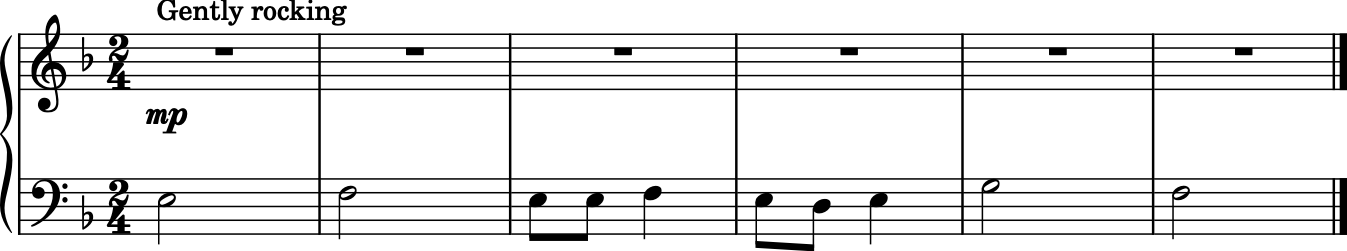

In [40]:
exercise, params = generate_exercise(
    pitch_markov_prob,
    rhythm_dict,
    grade="initial"
)

render_exercise(exercise, params)

bar_number = 1
rhythm = (0.5, 0.25, 0.25, 0.5, 0.5, 0.5, 0.5)
type(rhythm) = <class 'tuple'>
rhythm_plan = [(0.5, 0.25, 0.25, 0.5, 0.5, 0.5, 0.5), (0.5, 1.0, 1.5), (1.0, 0.5, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25), (0.25, 0.25, 0.5, 0.5, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25), (0.25, 0.25, 0.25, 0.25, 0.5, 0.25, 0.25, 0.25, 0.25, 0.5), (1.0, 0.5, 1.5), (0.5, 0.25, 0.25, 0.5, 0.5, 0.5, 0.5), (0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.5, 0.5, 0.5)]
bar_number = 2
rhythm = (0.5, 1.0, 1.5)
type(rhythm) = <class 'tuple'>
rhythm_plan = [(0.5, 0.25, 0.25, 0.5, 0.5, 0.5, 0.5), (0.5, 1.0, 1.5), (1.0, 0.5, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25), (0.25, 0.25, 0.5, 0.5, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25), (0.25, 0.25, 0.25, 0.25, 0.5, 0.25, 0.25, 0.25, 0.25, 0.5), (1.0, 0.5, 1.5), (0.5, 0.25, 0.25, 0.5, 0.5, 0.5, 0.5), (0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.5, 0.5, 0.5)]
bar_number = 3
rhythm = (1.0, 0.5, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25)
type(rhythm) = <class 'tuple'>
rhythm_plan = [(0.5, 0.25, 0.25, 0.5, 

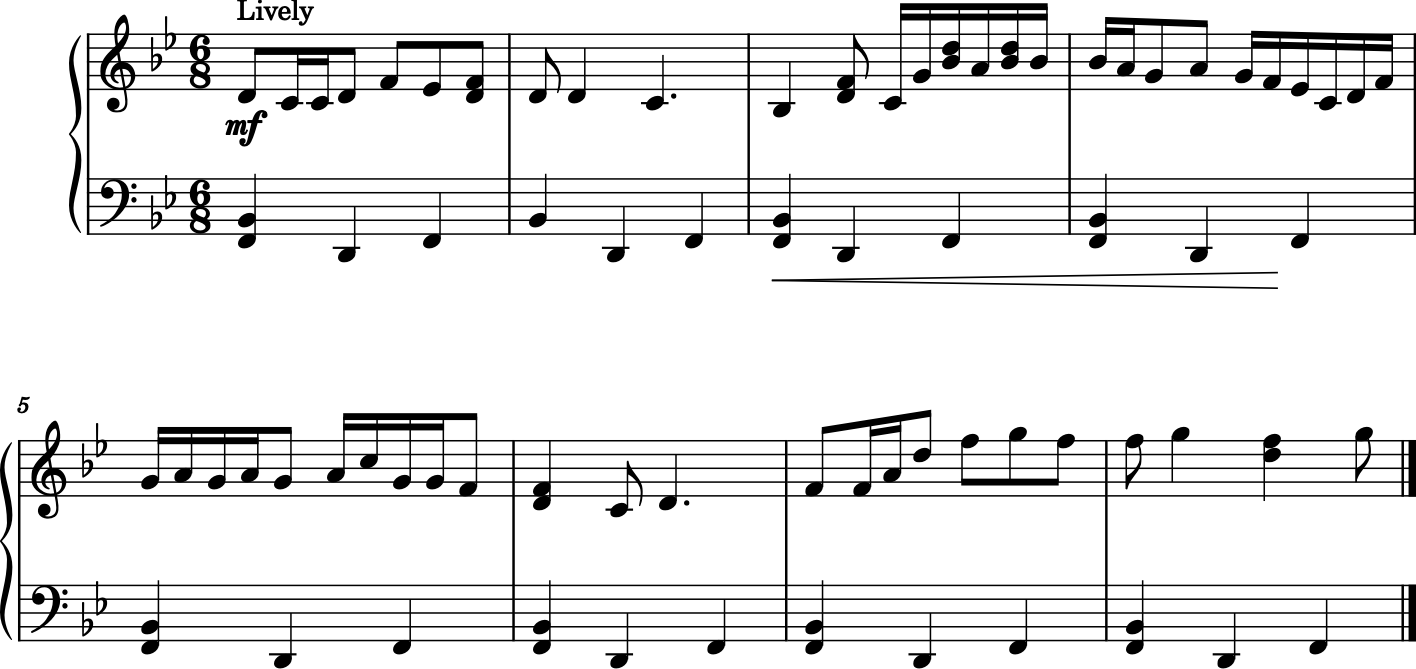

In [21]:
exercise, params = generate_exercise(
    pitch_markov_prob,
    rhythm_dict,
    grade=4
)

render_exercise(exercise, params)

bar_number = 1
rhythm = (1.0, 0.5, 1.5)
type(rhythm) = <class 'tuple'>
rhythm_plan = [(1.0, 0.5, 1.5), (0.5, 0.5, 0.5, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25), (0.75, 0.25, 0.25, 0.25, 0.5, 0.5, 0.5), (0.5, 0.25, 0.25, 0.5, 1.5), (0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 1.5), (1.0, 0.5, 1.5), (0.5, 0.75, 0.25, 0.5, 1.0), (1.0, 0.5, 0.5, 0.25, 0.25, 0.5)]
bar_number = 2
rhythm = (0.5, 0.5, 0.5, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25)
type(rhythm) = <class 'tuple'>
rhythm_plan = [(1.0, 0.5, 1.5), (0.5, 0.5, 0.5, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25), (0.75, 0.25, 0.25, 0.25, 0.5, 0.5, 0.5), (0.5, 0.25, 0.25, 0.5, 1.5), (0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 1.5), (1.0, 0.5, 1.5), (0.5, 0.75, 0.25, 0.5, 1.0), (1.0, 0.5, 0.5, 0.25, 0.25, 0.5)]
bar_number = 3
rhythm = (0.75, 0.25, 0.25, 0.25, 0.5, 0.5, 0.5)
type(rhythm) = <class 'tuple'>
rhythm_plan = [(1.0, 0.5, 1.5), (0.5, 0.5, 0.5, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25), (0.75, 0.25, 0.25, 0.25, 0.5, 0.5, 0.5), (0.5, 0.25, 0.25, 0.5, 1.5), (0.25, 0.25, 0.2

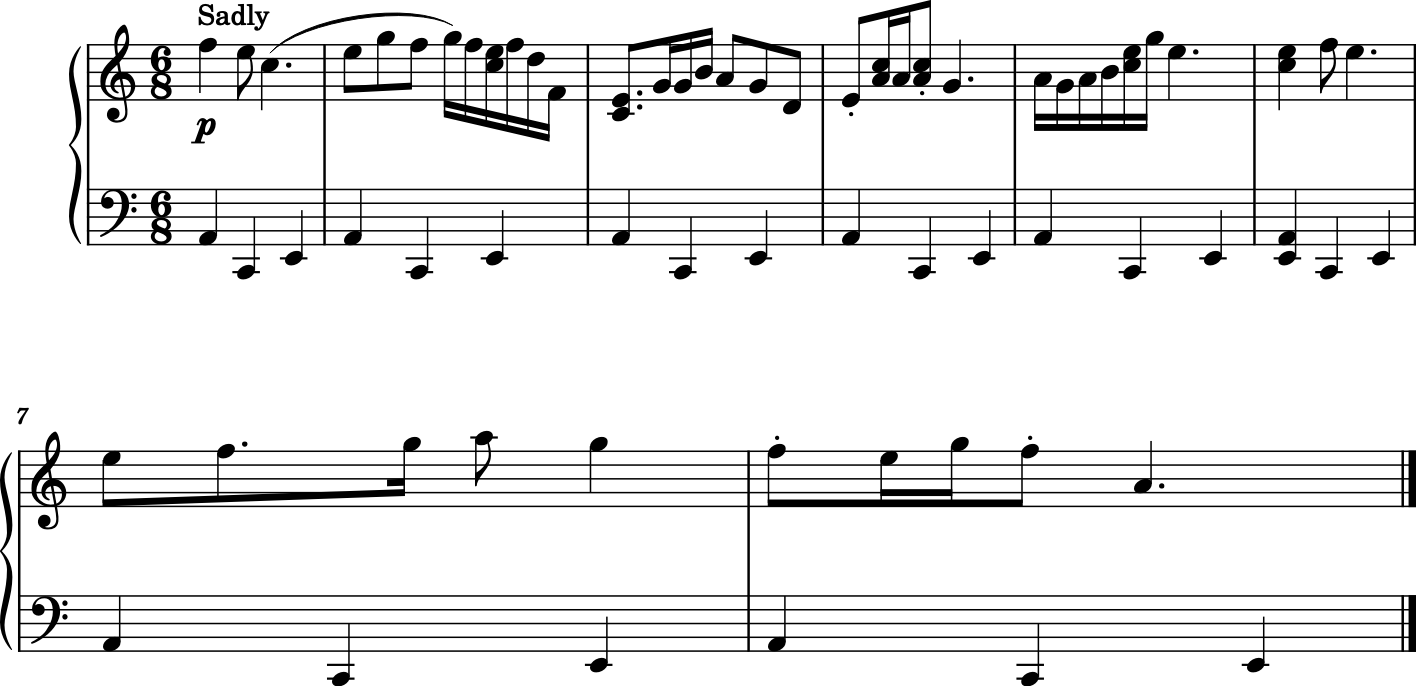

In [33]:
exercise, params = generate_exercise(
    pitch_markov_prob,
    rhythm_dict,
    grade=4
)

render_exercise(exercise, params)

In [25]:
exercise, params = generate_exercise(
    pitch_markov_prob,
    rhythm_dict,
    grade=4
)

render_exercise(exercise, params)

Hand pattern: ['RL', 'RL', 'RL', 'R']
(0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25) 3
(0.5, 0.5, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25) 23
(1.0, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25) 2
(0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 1.0) 21
(0.5, 0.5, 0.5, 0.5, 0.5, 0.5) 2
(1.0, 0.5, 0.25, 0.25, 0.75, 0.25) 2
(1.5, 0.25, 0.25, 0.75, 0.25) 22
(0.75, 0.25, 1.0, 0.75, 0.25) 2
(3.0,) 2
(1.0, 1.0, 1.0) 4
(2.0, 1.0) 2
(0.5, 0.5, 0.5, 0.5, 1.0) 168
(0.5, 0.5, 1.0, 1.0) 2
(0.5, 0.5, 2.0) 6
(1.0, 0.5, 0.5, 0.5, 0.5) 7
(1.0, 2.0) 2
(1.0, 1.5, 0.5) 2
(0.5, 0.5, 1.5, 0.5) 2
(1.0, 1.0, 0.5, 0.5) 1
(0.5, 0.25, 0.25, 0.5, 0.5, 0.5, 0.5) 83
(0.25, 0.25, 0.25, 0.25, 1.0, 1.0) 30
(1.0, 0.75, 0.25, 1.0) 1
(0.25, 0.25, 0.5, 0.5, 0.5, 0.5, 0.5) 6
(1.0, 1.0, 0.25, 0.25, 0.5) 4
(1.0, 0.5, 0.5, 1.0) 6
(1.5, 0.25, 0.25, 1.0) 10
(0.25, 0.25, 0.5, 2.0) 5
(0.5, 0.25, 0.25, 0.5, 0.25, 0.25, 1.0) 9
(0.5, 0.25, 0.25, 0.5, 0.5, 1.0) 1
(0.5, 0.25, 0.25, 1.0, 1.0) 18
(0.25

TypeError: 'NoneType' object is not iterable

Hand pattern: ['RL', 'BOTH', 'LR', 'RL']
(4.0,) 4
(1.5, 0.5, 0.5, 0.5, 0.5, 0.5) 2
(1.0, 0.5, 0.5, 0.5, 0.5, 1.0) 1
(0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 1.0) 44
(0.75, 0.25, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5) 5
(0.5, 0.5, 1.0, 1.0, 1.0) 1
(1.0, 1.0, 0.5, 0.5, 0.5, 0.5) 1
(1.0, 0.75, 0.25, 0.5, 0.5, 0.5, 0.5) 7
(1.0, 1.0, 1.0, 1.0) 2
(0.5, 0.5, 3.0) 19
(1.0, 0.5, 0.5, 0.5, 0.5, 0.5, 0.25, 0.25) 1
(1.0, 1.0, 1.0, 0.5, 0.25, 0.25) 2
(1.0, 1.0, 0.25, 0.25, 0.5, 1.0) 2
(1.0, 3.0) 11
(1.0, 1.0, 0.5, 0.25, 0.25, 1.0) 1
(0.5, 0.5, 2.0, 1.0) 10
(0.5, 1.0, 0.5, 0.25, 0.25, 1.5) 2
(0.5, 1.0, 0.5, 0.25, 0.25, 0.5, 0.5, 0.5) 2
(0.5, 1.0, 0.5, 0.5, 1.0, 0.5) 27
(0.5, 0.5, 0.5, 0.5, 0.5, 1.0, 0.5) 16
(0.5, 0.5, 1.0, 0.5, 0.5, 1.0) 32
(0.5, 0.5, 1.0, 0.5, 0.5, 0.5, 0.5) 1
(0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5) 1
(0.5, 0.5, 1.0, 2.0) 36
(0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25) 1
(0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.5, 

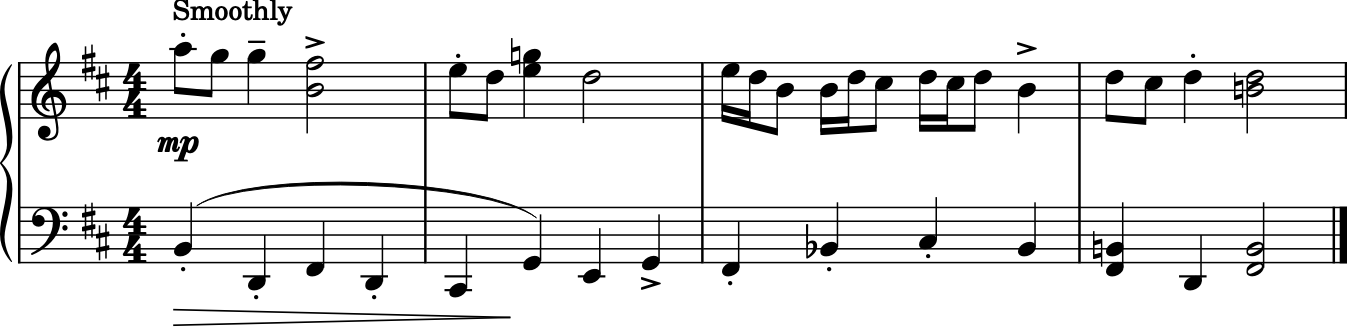

In [33]:

exercise, params = generate_exercise(
        pitch_markov_prob,
        rhythm_dict,
        grade=4
    )

render_exercise(exercise, params)

bar_number = 1
rhythm = (0.5, 0.25, 0.25, 0.5)
type(rhythm) = <class 'tuple'>
rhythm_plan = [(0.5, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25), (0.5, 0.25, 0.25, 0.25, 0.25, 0.5, 0.5, 0.5), (0.5, 0.25, 0.25, 0.5, 0.5, 0.5, 0.5), (0.25, 0.25, 0.5, 0.5, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25), (1.0, 0.5, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25), (1.0, 1.0, 1.0), (1.0, 0.5, 0.5, 0.25, 0.25, 0.25, 0.25), (0.75, 1.5, 0.75)]
bar_number = 2
rhythm = (0.5, 0.25, 0.25, 0.25, 0.25, 0.5, 0.5, 0.5)
type(rhythm) = <class 'tuple'>
rhythm_plan = [(0.5, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25), (0.5, 0.25, 0.25, 0.25, 0.25, 0.5, 0.5, 0.5), (0.5, 0.25, 0.25, 0.5, 0.5, 0.5, 0.5), (0.25, 0.25, 0.5, 0.5, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25), (1.0, 0.5, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25), (1.0, 1.0, 1.0), (1.0, 0.5, 0.5, 0.25, 0.25, 0.25, 0.25), (0.75, 1.5, 0.75)]
bar_number = 3
rhythm = (0.5, 0.25, 0.25, 0.5, 0.5, 0.5, 0.5)
type(rhythm) = <class 'tuple'>
rhythm_plan = [(0.5, 0.25

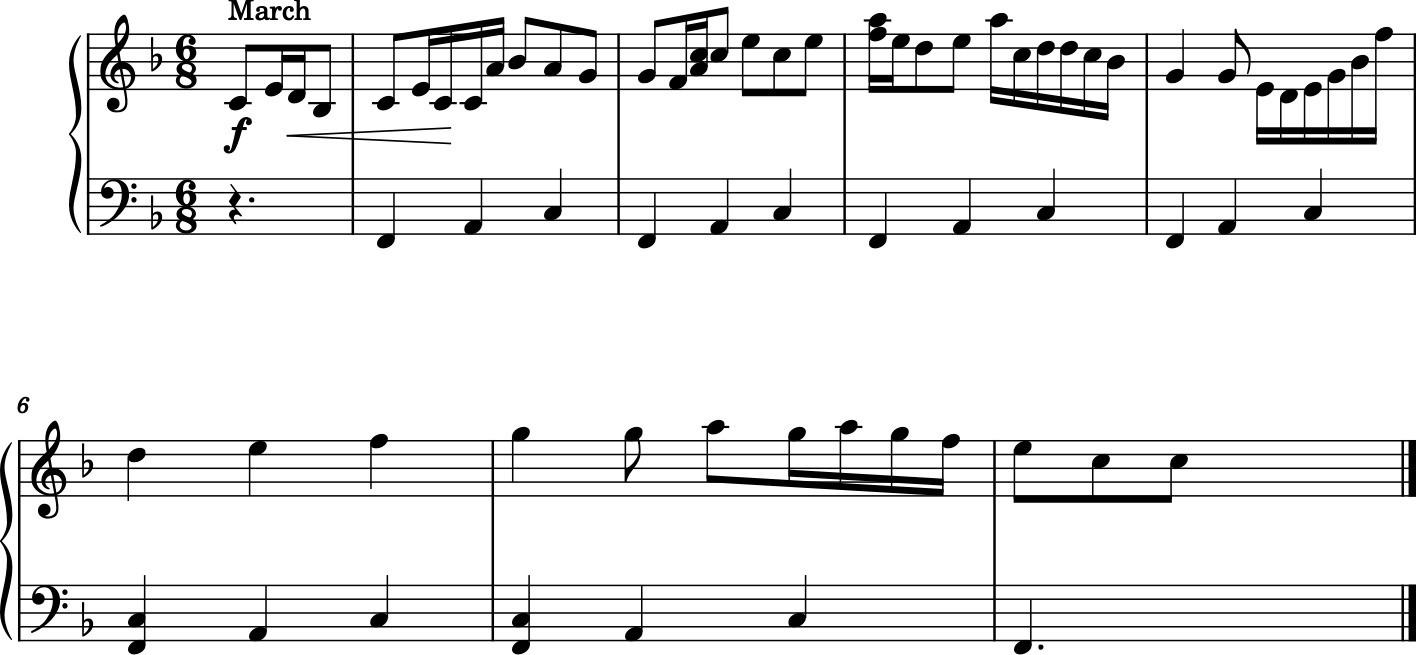

bar_number = 1
rhythm = (0.25, 0.25)
type(rhythm) = <class 'tuple'>
rhythm_plan = [(0.75, 0.25, 0.5, 0.5), (0.75, 0.25, 0.5, 0.5), (0.25, 0.25, 0.25, 0.25, 0.5, 0.25, 0.25), (0.25, 0.25, 0.25, 0.25, 0.5, 0.25, 0.25), (0.75, 0.25, 0.5, 0.5), (0.25, 0.5, 0.25, 0.25, 0.5, 0.25)]
bar_number = 2
rhythm = (0.75, 0.25, 0.5, 0.5)
type(rhythm) = <class 'tuple'>
rhythm_plan = [(0.75, 0.25, 0.5, 0.5), (0.75, 0.25, 0.5, 0.5), (0.25, 0.25, 0.25, 0.25, 0.5, 0.25, 0.25), (0.25, 0.25, 0.25, 0.25, 0.5, 0.25, 0.25), (0.75, 0.25, 0.5, 0.5), (0.25, 0.5, 0.25, 0.25, 0.5, 0.25)]
bar_number = 3
rhythm = (0.25, 0.25, 0.25, 0.25, 0.5, 0.25, 0.25)
type(rhythm) = <class 'tuple'>
rhythm_plan = [(0.75, 0.25, 0.5, 0.5), (0.75, 0.25, 0.5, 0.5), (0.25, 0.25, 0.25, 0.25, 0.5, 0.25, 0.25), (0.25, 0.25, 0.25, 0.25, 0.5, 0.25, 0.25), (0.75, 0.25, 0.5, 0.5), (0.25, 0.5, 0.25, 0.25, 0.5, 0.25)]
bar_number = 4
rhythm = (0.25, 0.25, 0.25, 0.25, 0.5, 0.25, 0.25)
type(rhythm) = <class 'tuple'>
rhythm_plan = [(0.75, 0.25, 0.5, 

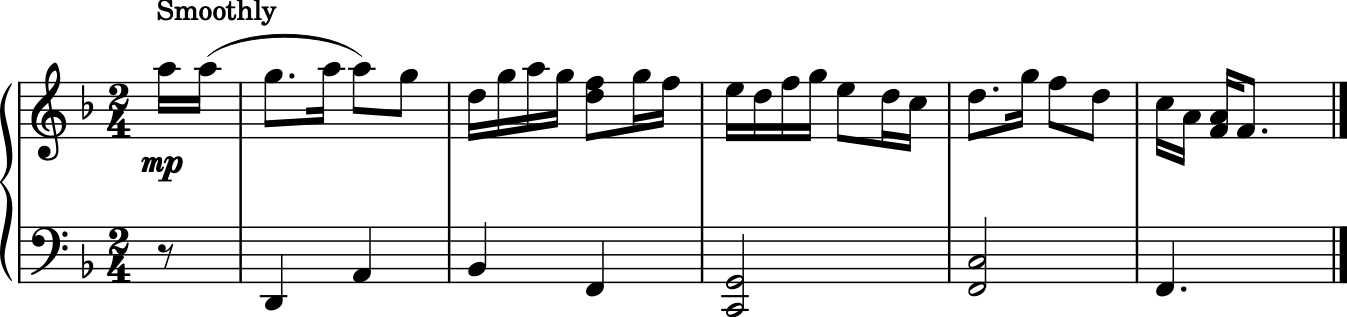

bar_number = 1
rhythm = (1.0, 0.5)
type(rhythm) = <class 'tuple'>
rhythm_plan = [(1.5, 1.5), (0.5, 0.5, 0.5, 1.5), (0.5, 0.25, 0.25, 0.25, 0.25, 0.5, 0.25, 0.25, 0.25, 0.25), (1.0, 0.5, 0.5, 1.0), (1.0, 0.5, 0.5, 0.25, 0.25, 0.25, 0.25), (0.5, 0.5, 0.5, 0.75, 0.75), (0.75, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25), (1.0, 0.5, 0.5, 1.0)]
bar_number = 2
rhythm = (0.5, 0.5, 0.5, 1.5)
type(rhythm) = <class 'tuple'>
rhythm_plan = [(1.5, 1.5), (0.5, 0.5, 0.5, 1.5), (0.5, 0.25, 0.25, 0.25, 0.25, 0.5, 0.25, 0.25, 0.25, 0.25), (1.0, 0.5, 0.5, 1.0), (1.0, 0.5, 0.5, 0.25, 0.25, 0.25, 0.25), (0.5, 0.5, 0.5, 0.75, 0.75), (0.75, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25), (1.0, 0.5, 0.5, 1.0)]
bar_number = 3
rhythm = (0.5, 0.25, 0.25, 0.25, 0.25, 0.5, 0.25, 0.25, 0.25, 0.25)
type(rhythm) = <class 'tuple'>
rhythm_plan = [(1.5, 1.5), (0.5, 0.5, 0.5, 1.5), (0.5, 0.25, 0.25, 0.25, 0.25, 0.5, 0.25, 0.25, 0.25, 0.25), (1.0, 0.5, 0.5, 1.0), (1.0, 0.5, 0.5, 0.25, 0.25, 0.25, 0.25), (0

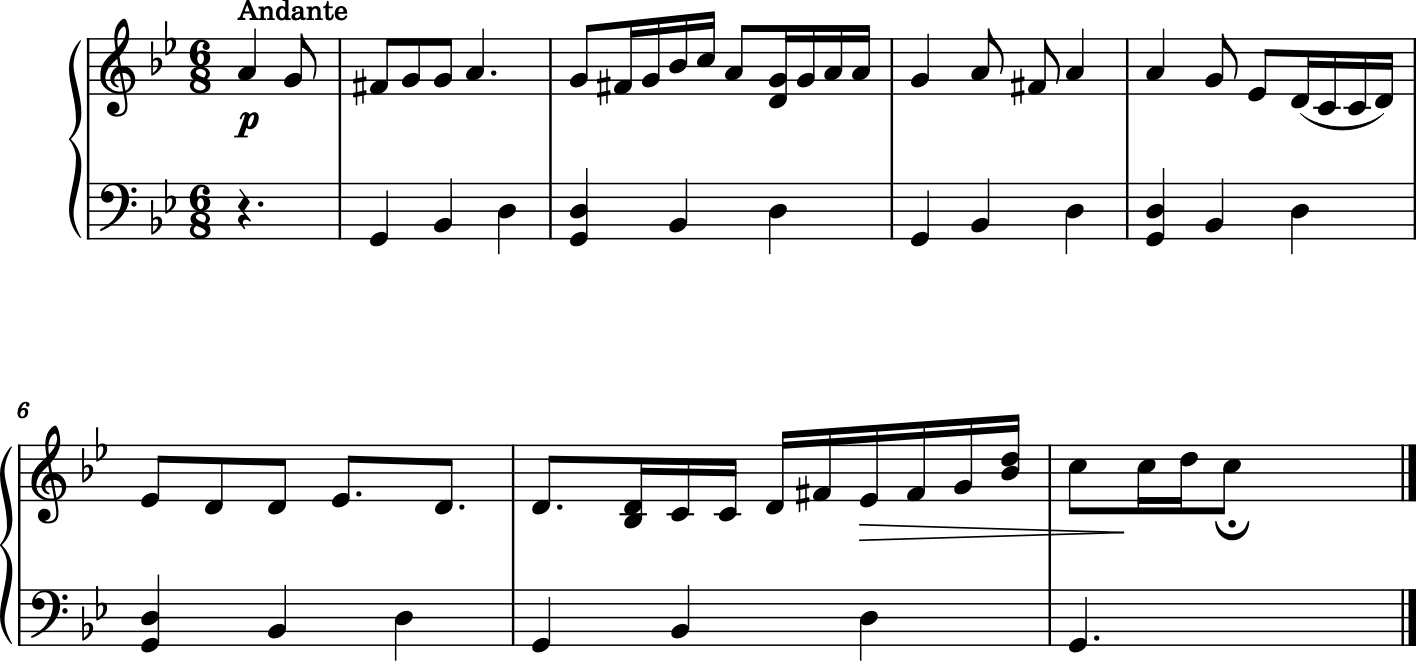

bar_number = 1
rhythm = (0.5, 0.25, 0.25)
type(rhythm) = <class 'tuple'>
rhythm_plan = [(0.5, 0.25, 0.25, 0.5), (0.25, 0.25, 1.0), (0.75, 0.25, 0.5), (0.25, 0.5, 0.5, 0.25), (0.5, 0.25, 0.25, 0.25, 0.25), (1.0, 0.25, 0.25), (0.25, 0.25, 0.75, 0.25), (1.0, 0.25, 0.25)]
bar_number = 2
rhythm = (0.25, 0.25, 1.0)
type(rhythm) = <class 'tuple'>
rhythm_plan = [(0.5, 0.25, 0.25, 0.5), (0.25, 0.25, 1.0), (0.75, 0.25, 0.5), (0.25, 0.5, 0.5, 0.25), (0.5, 0.25, 0.25, 0.25, 0.25), (1.0, 0.25, 0.25), (0.25, 0.25, 0.75, 0.25), (1.0, 0.25, 0.25)]
bar_number = 3
rhythm = (0.75, 0.25, 0.5)
type(rhythm) = <class 'tuple'>
rhythm_plan = [(0.5, 0.25, 0.25, 0.5), (0.25, 0.25, 1.0), (0.75, 0.25, 0.5), (0.25, 0.5, 0.5, 0.25), (0.5, 0.25, 0.25, 0.25, 0.25), (1.0, 0.25, 0.25), (0.25, 0.25, 0.75, 0.25), (1.0, 0.25, 0.25)]
bar_number = 4
rhythm = (0.25, 0.5, 0.5, 0.25)
type(rhythm) = <class 'tuple'>
rhythm_plan = [(0.5, 0.25, 0.25, 0.5), (0.25, 0.25, 1.0), (0.75, 0.25, 0.5), (0.25, 0.5, 0.5, 0.25), (0.5, 0.25, 0.

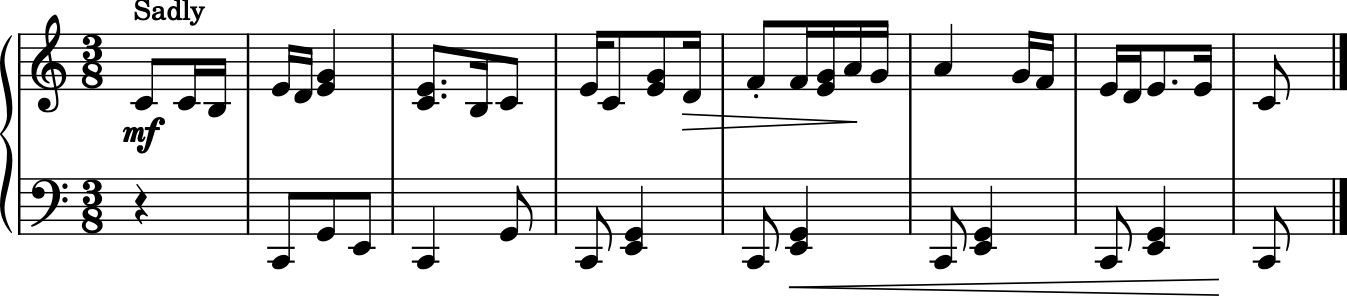

bar_number = 1
rhythm = (0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 1.0, 0.25, 0.25, 0.25, 0.25)
type(rhythm) = <class 'tuple'>
rhythm_plan = [(0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 1.0, 0.25, 0.25, 0.25, 0.25), (1.0, 0.5, 0.5, 1.0, 0.5, 0.5), (1.0, 0.75, 0.25, 0.75, 0.25, 0.75, 0.25), (0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 1.0), (0.5, 0.5, 1.0, 0.5, 0.5, 1.0), (0.5, 0.5, 0.5, 0.5, 1.0, 0.5, 0.25, 0.25), (0.75, 0.25, 1.0, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25), (1.5, 0.25, 0.25, 1.5, 0.25, 0.25)]
bar_number = 2
rhythm = (1.0, 0.5, 0.5, 1.0, 0.5, 0.5)
type(rhythm) = <class 'tuple'>
rhythm_plan = [(0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 1.0, 0.25, 0.25, 0.25, 0.25), (1.0, 0.5, 0.5, 1.0, 0.5, 0.5), (1.0, 0.75, 0.25, 0.75, 0.25, 0.75, 0.25), (0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 1.0), (0.5, 0.5, 1.0, 0.5, 0.5, 1.0), (0.5, 0.5, 0.5, 0.5, 1.0, 0.5, 0.25, 0.25), (0.75, 0.25, 1.0, 0.25, 0.25, 

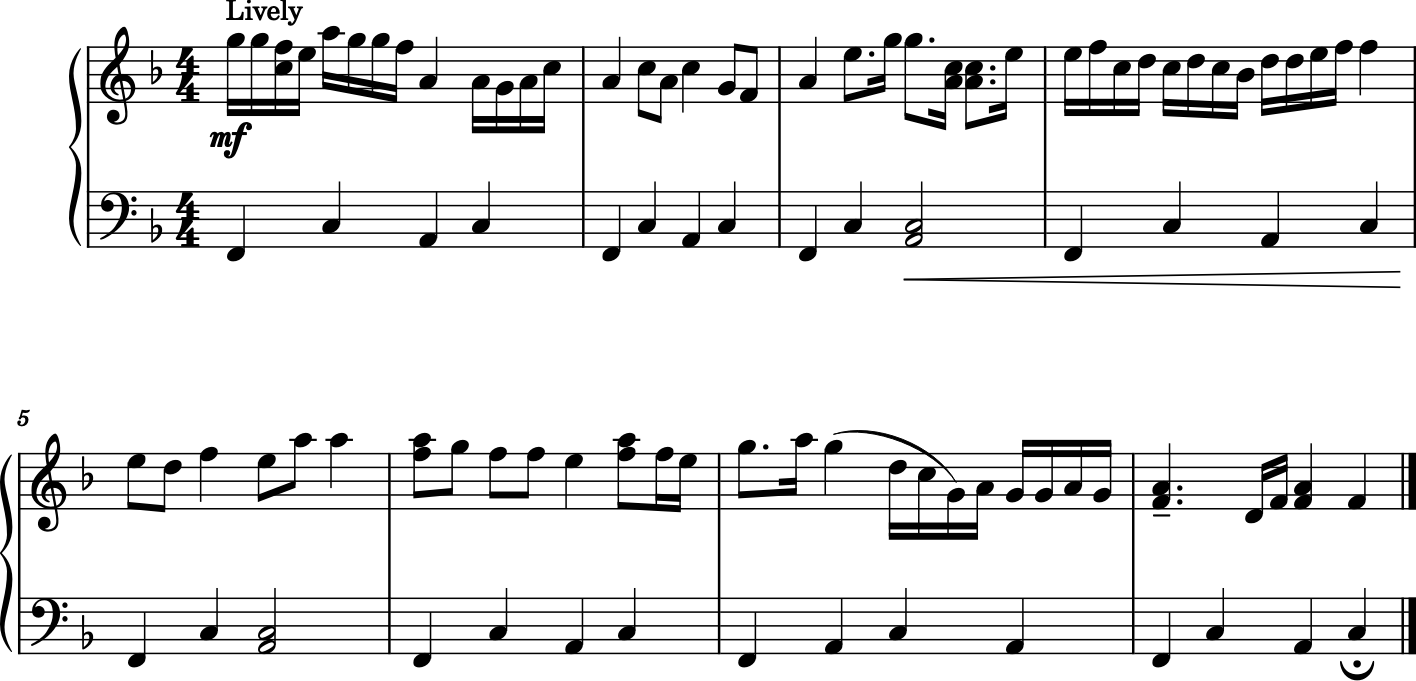

bar_number = 1
rhythm = (0.25, 0.25, 0.75, 0.25)
type(rhythm) = <class 'tuple'>
rhythm_plan = [(0.25, 0.25, 0.75, 0.25), (0.25, 0.25, 0.75, 0.25), (0.5, 0.25, 0.25, 0.5), (0.25, 0.25, 0.75, 0.25), (1.0, 0.25, 0.25), (0.25, 0.25, 0.75, 0.25), (0.25, 0.25, 0.75, 0.25), (0.25, 0.25, 1.0)]
bar_number = 2
rhythm = (0.25, 0.25, 0.75, 0.25)
type(rhythm) = <class 'tuple'>
rhythm_plan = [(0.25, 0.25, 0.75, 0.25), (0.25, 0.25, 0.75, 0.25), (0.5, 0.25, 0.25, 0.5), (0.25, 0.25, 0.75, 0.25), (1.0, 0.25, 0.25), (0.25, 0.25, 0.75, 0.25), (0.25, 0.25, 0.75, 0.25), (0.25, 0.25, 1.0)]
bar_number = 3
rhythm = (0.5, 0.25, 0.25, 0.5)
type(rhythm) = <class 'tuple'>
rhythm_plan = [(0.25, 0.25, 0.75, 0.25), (0.25, 0.25, 0.75, 0.25), (0.5, 0.25, 0.25, 0.5), (0.25, 0.25, 0.75, 0.25), (1.0, 0.25, 0.25), (0.25, 0.25, 0.75, 0.25), (0.25, 0.25, 0.75, 0.25), (0.25, 0.25, 1.0)]
bar_number = 4
rhythm = (0.25, 0.25, 0.75, 0.25)
type(rhythm) = <class 'tuple'>
rhythm_plan = [(0.25, 0.25, 0.75, 0.25), (0.25, 0.25, 0.75, 0

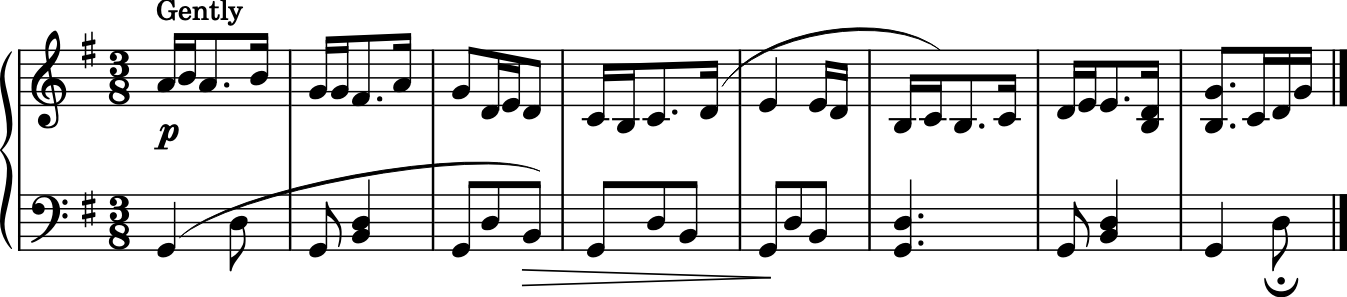

bar_number = 1
rhythm = (0.5,)
type(rhythm) = <class 'tuple'>
rhythm_plan = [(0.75, 0.25, 0.25, 0.25), (0.75, 0.25, 0.5), (0.75, 0.25, 0.5), (0.25, 0.25, 0.75, 0.25), (0.25, 0.25, 0.75, 0.25), (0.25, 0.5, 0.5, 0.25), (0.25, 0.25, 1.0), (0.25, 0.25, 0.5, 0.5)]
bar_number = 2
rhythm = (0.75, 0.25, 0.5)
type(rhythm) = <class 'tuple'>
rhythm_plan = [(0.75, 0.25, 0.25, 0.25), (0.75, 0.25, 0.5), (0.75, 0.25, 0.5), (0.25, 0.25, 0.75, 0.25), (0.25, 0.25, 0.75, 0.25), (0.25, 0.5, 0.5, 0.25), (0.25, 0.25, 1.0), (0.25, 0.25, 0.5, 0.5)]
bar_number = 3
rhythm = (0.75, 0.25, 0.5)
type(rhythm) = <class 'tuple'>
rhythm_plan = [(0.75, 0.25, 0.25, 0.25), (0.75, 0.25, 0.5), (0.75, 0.25, 0.5), (0.25, 0.25, 0.75, 0.25), (0.25, 0.25, 0.75, 0.25), (0.25, 0.5, 0.5, 0.25), (0.25, 0.25, 1.0), (0.25, 0.25, 0.5, 0.5)]
bar_number = 4
rhythm = (0.25, 0.25, 0.75, 0.25)
type(rhythm) = <class 'tuple'>
rhythm_plan = [(0.75, 0.25, 0.25, 0.25), (0.75, 0.25, 0.5), (0.75, 0.25, 0.5), (0.25, 0.25, 0.75, 0.25), (0.25, 0.25, 

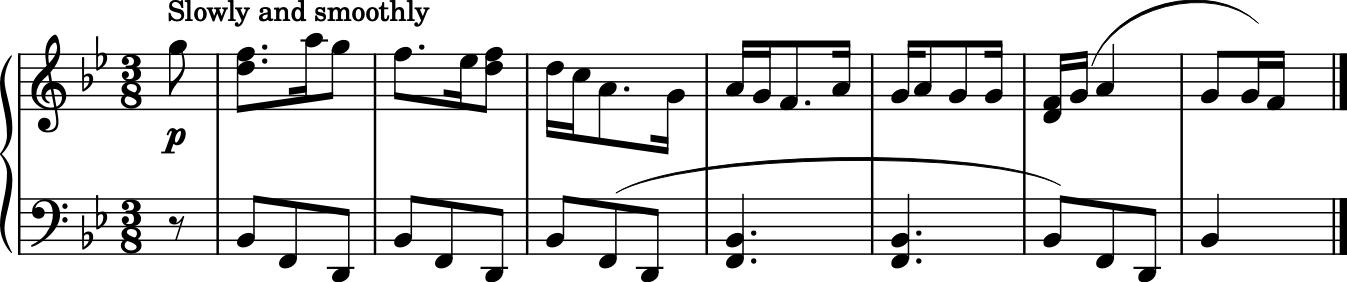

bar_number = 1
rhythm = (0.75, 0.25, 0.75, 0.25)
type(rhythm) = <class 'tuple'>
rhythm_plan = [(0.75, 0.25, 0.75, 0.25), (0.25, 0.25, 0.25, 0.25, 1.0), (0.75, 0.25, 0.75, 0.25), (0.5, 0.5, 0.25, 0.75), (0.25, 0.25, 0.5, 0.25, 0.75), (0.25, 0.25, 0.25, 0.25, 0.5, 0.25, 0.25), (0.25, 0.25, 0.25, 0.25, 1.0), (1.0, 1.0)]
bar_number = 2
rhythm = (0.25, 0.25, 0.25, 0.25, 1.0)
type(rhythm) = <class 'tuple'>
rhythm_plan = [(0.75, 0.25, 0.75, 0.25), (0.25, 0.25, 0.25, 0.25, 1.0), (0.75, 0.25, 0.75, 0.25), (0.5, 0.5, 0.25, 0.75), (0.25, 0.25, 0.5, 0.25, 0.75), (0.25, 0.25, 0.25, 0.25, 0.5, 0.25, 0.25), (0.25, 0.25, 0.25, 0.25, 1.0), (1.0, 1.0)]
bar_number = 3
rhythm = (0.75, 0.25, 0.75, 0.25)
type(rhythm) = <class 'tuple'>
rhythm_plan = [(0.75, 0.25, 0.75, 0.25), (0.25, 0.25, 0.25, 0.25, 1.0), (0.75, 0.25, 0.75, 0.25), (0.5, 0.5, 0.25, 0.75), (0.25, 0.25, 0.5, 0.25, 0.75), (0.25, 0.25, 0.25, 0.25, 0.5, 0.25, 0.25), (0.25, 0.25, 0.25, 0.25, 1.0), (1.0, 1.0)]
bar_number = 4
rhythm = (0.5, 0.5, 0.2

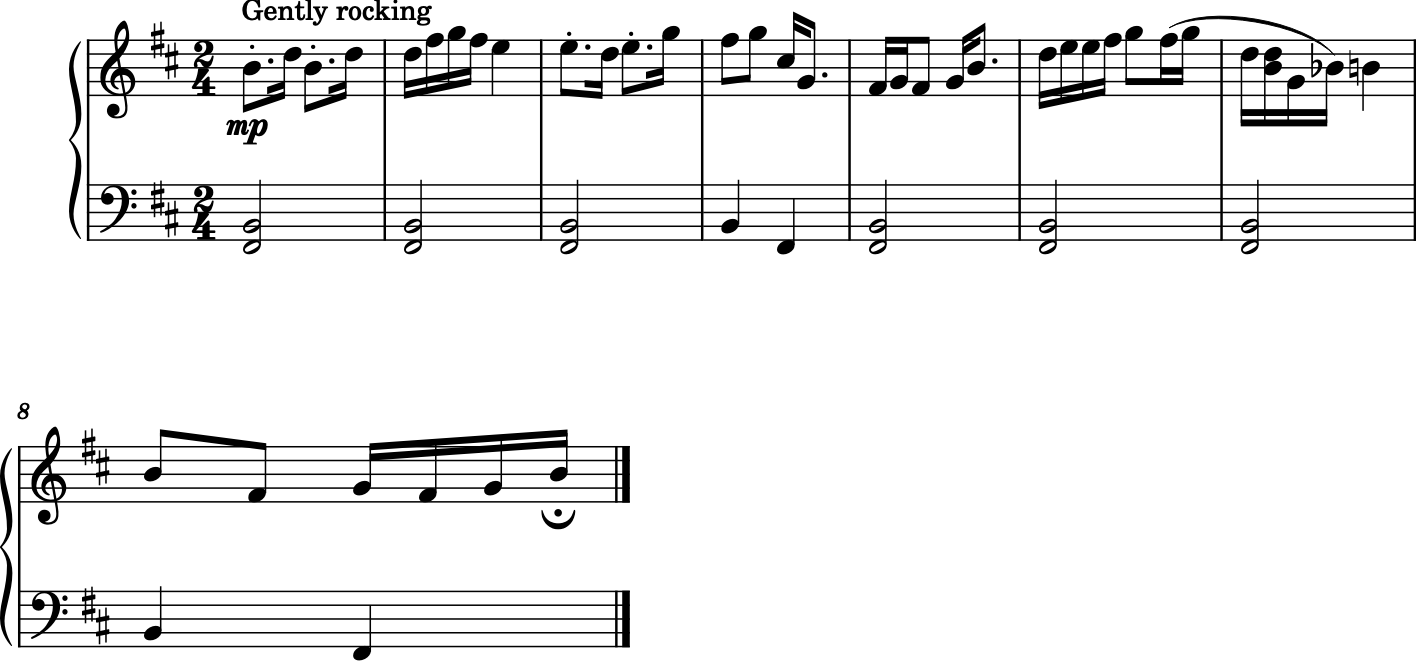

bar_number = 1
rhythm = (1.5, 0.5, 0.75, 0.25)
type(rhythm) = <class 'tuple'>
rhythm_plan = [(1.5, 0.5, 0.75, 0.25), (0.75, 0.25, 0.25, 0.25, 0.5, 0.5, 0.5), (0.5, 0.25, 0.25, 0.5, 1.5), (0.5, 0.5, 0.5, 1.5), (1.0, 1.0, 1.0), (0.5, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25), (1.0, 1.0, 1.0), (0.5, 0.25, 0.25, 0.5, 0.5, 0.5, 0.5)]
bar_number = 2
rhythm = (0.75, 0.25, 0.25, 0.25, 0.5, 0.5, 0.5)
type(rhythm) = <class 'tuple'>
rhythm_plan = [(1.5, 0.5, 0.75, 0.25), (0.75, 0.25, 0.25, 0.25, 0.5, 0.5, 0.5), (0.5, 0.25, 0.25, 0.5, 1.5), (0.5, 0.5, 0.5, 1.5), (1.0, 1.0, 1.0), (0.5, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25), (1.0, 1.0, 1.0), (0.5, 0.25, 0.25, 0.5, 0.5, 0.5, 0.5)]
bar_number = 3
rhythm = (0.5, 0.25, 0.25, 0.5, 1.5)
type(rhythm) = <class 'tuple'>
rhythm_plan = [(1.5, 0.5, 0.75, 0.25), (0.75, 0.25, 0.25, 0.25, 0.5, 0.5, 0.5), (0.5, 0.25, 0.25, 0.5, 1.5), (0.5, 0.5, 0.5, 1.5), (1.0, 1.0, 1.0), (0.5, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 

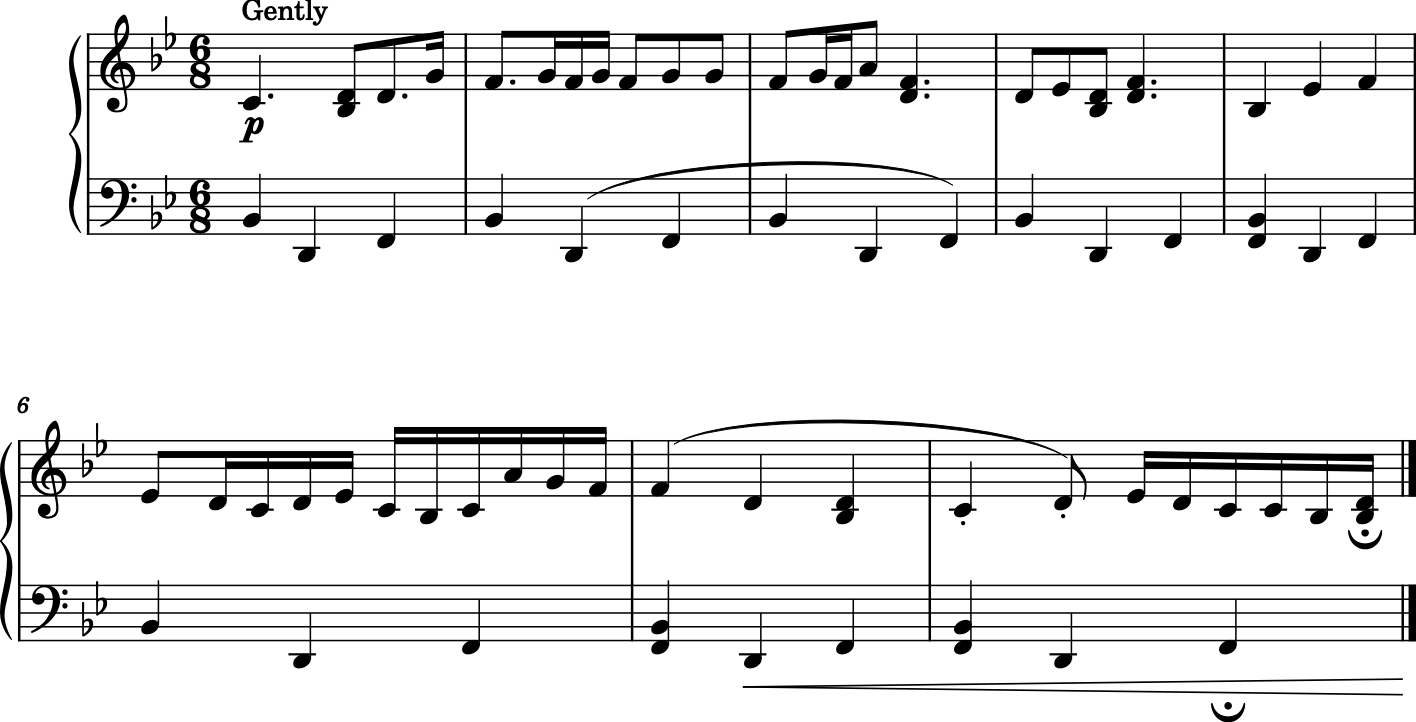

bar_number = 1
rhythm = (0.5, 0.25, 0.25, 0.5)
type(rhythm) = <class 'tuple'>
rhythm_plan = [(0.5, 0.25, 0.25, 0.5), (1.0, 0.25, 0.25), (0.5, 0.25, 0.25, 0.25, 0.25), (0.5, 0.25, 0.25, 0.25, 0.25), (0.25, 0.25, 1.0), (0.25, 0.25, 0.75, 0.25), (0.5, 0.25, 0.25, 0.5), (1.0, 0.25, 0.25)]
bar_number = 2
rhythm = (1.0, 0.25, 0.25)
type(rhythm) = <class 'tuple'>
rhythm_plan = [(0.5, 0.25, 0.25, 0.5), (1.0, 0.25, 0.25), (0.5, 0.25, 0.25, 0.25, 0.25), (0.5, 0.25, 0.25, 0.25, 0.25), (0.25, 0.25, 1.0), (0.25, 0.25, 0.75, 0.25), (0.5, 0.25, 0.25, 0.5), (1.0, 0.25, 0.25)]
bar_number = 3
rhythm = (0.5, 0.25, 0.25, 0.25, 0.25)
type(rhythm) = <class 'tuple'>
rhythm_plan = [(0.5, 0.25, 0.25, 0.5), (1.0, 0.25, 0.25), (0.5, 0.25, 0.25, 0.25, 0.25), (0.5, 0.25, 0.25, 0.25, 0.25), (0.25, 0.25, 1.0), (0.25, 0.25, 0.75, 0.25), (0.5, 0.25, 0.25, 0.5), (1.0, 0.25, 0.25)]
bar_number = 4
rhythm = (0.5, 0.25, 0.25, 0.25, 0.25)
type(rhythm) = <class 'tuple'>
rhythm_plan = [(0.5, 0.25, 0.25, 0.5), (1.0, 0.25, 0.25

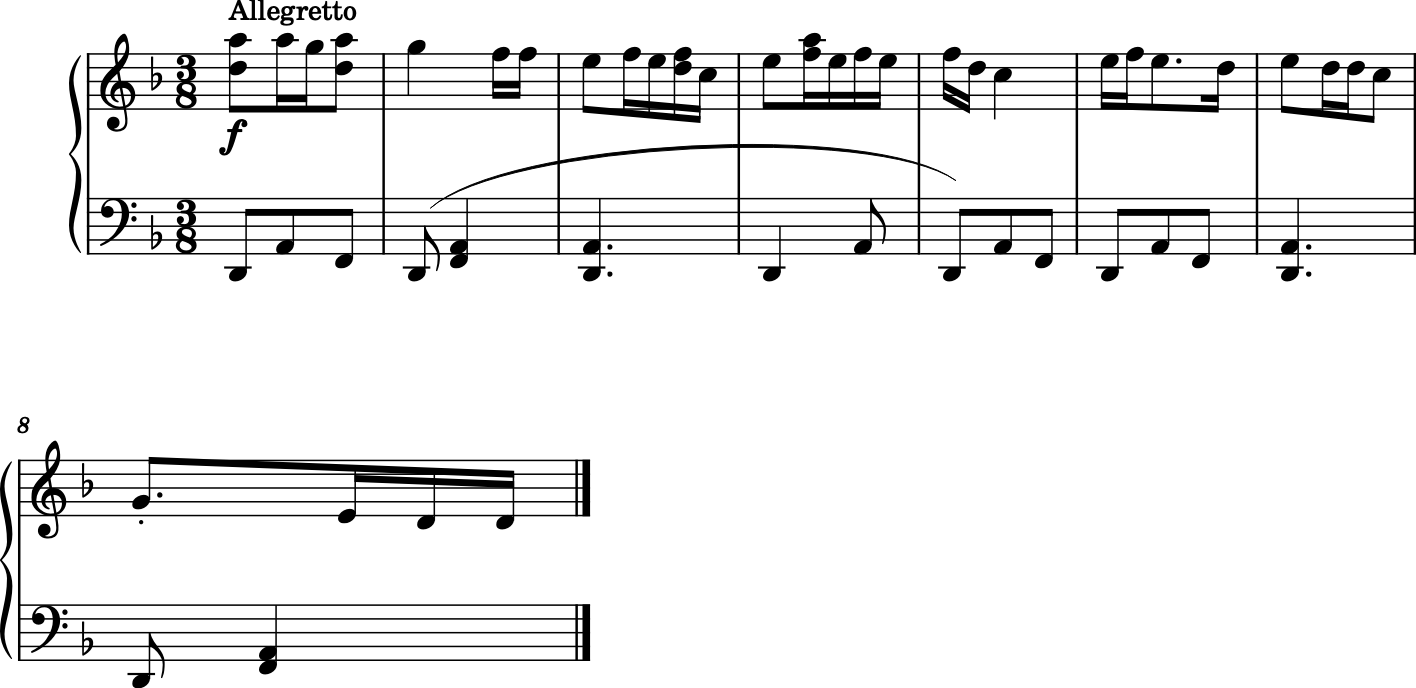

In [18]:
for i in range(10):
    exercise, params = generate_exercise(
        pitch_markov_prob,
        rhythm_dict,
        grade=4
    )

    render_exercise(exercise, params)

Hand pattern: ['L', 'L', 'R', 'R']
(0.5, 0.5, 0.5, 0.5, 0.5, 0.5) 2
(1.0, 1.0, 1.0) 4
(2.0, 1.0) 2
(0.5, 0.5, 0.5, 0.5, 1.0) 168
(0.5, 0.5, 1.0, 1.0) 2
(0.5, 0.5, 2.0) 6
(1.0, 0.5, 0.5, 0.5, 0.5) 7
(1.0, 2.0) 2
(1.0, 1.5, 0.5) 2
(0.5, 0.5, 1.5, 0.5) 2
(1.0, 1.0, 0.5, 0.5) 1
(1.0, 0.5, 0.5, 1.0) 6
(2.0, 0.5, 0.5) 4
(1.5, 0.5, 0.5, 0.5) 4
(0.5, 0.5, 1.0, 0.5, 0.5) 2
(1.5, 0.5, 1.0) 7
(0.5, 1.0, 0.5, 1.0) 1
(0.5, 1.0, 0.5, 0.5, 0.5) 1
(0.5, 2.0, 0.5) 11
(1.0, 0.5, 1.0, 0.5) 4
(0.5, 0.5, 0.5, 1.0, 0.5) 4
(0.5, 1.5, 1.0) 2
(1.0, 0.5, 1.5) 4
(0.5, 1.0, 1.0, 0.5) 1
(0.5, 1.0, 1.5) 1
rhythm_plan: [(0.5, 0.5, 0.5, 0.5, 1.0), (0.5, 0.5, 0.5, 0.5, 1.0), (1.0, 1.0, 1.0), (0.5, 0.5, 0.5, 0.5, 1.0)]
generate_exercise: position_notes:[59, 60, 62, 64, 66]
generate_exercise: allowed_notes:[60, 62, 64, 66]
bar 1, attemt number 0
constrained_transitions: max_interval = 5
constrained_transitions: allowed_notes = [60, 62, 64, 66]
constrained_transitions: filtered after loop:{64: 0.05489669575594838, 60: 0.

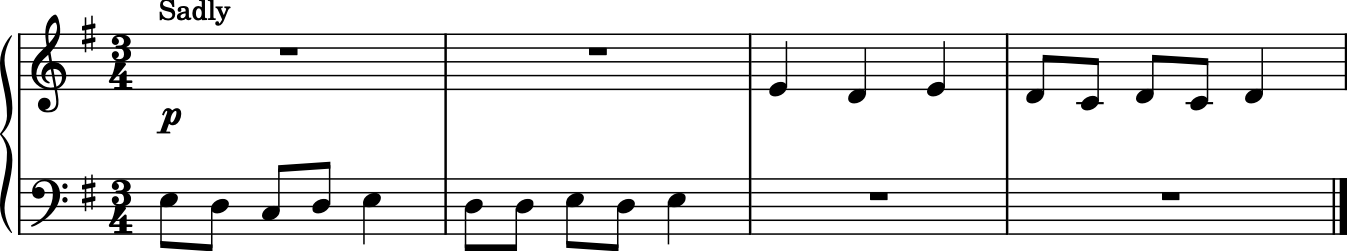

Hand pattern: ['R', 'R', 'L', 'L']
(0.5, 0.5, 0.5, 0.5, 0.5, 0.5) 2
(1.0, 1.0, 1.0) 4
(2.0, 1.0) 2
(0.5, 0.5, 0.5, 0.5, 1.0) 168
(0.5, 0.5, 1.0, 1.0) 2
(0.5, 0.5, 2.0) 6
(1.0, 0.5, 0.5, 0.5, 0.5) 7
(1.0, 2.0) 2
(1.0, 1.5, 0.5) 2
(0.5, 0.5, 1.5, 0.5) 2
(1.0, 1.0, 0.5, 0.5) 1
(1.0, 0.5, 0.5, 1.0) 6
(2.0, 0.5, 0.5) 4
(1.5, 0.5, 0.5, 0.5) 4
(0.5, 0.5, 1.0, 0.5, 0.5) 2
(1.5, 0.5, 1.0) 7
(0.5, 1.0, 0.5, 1.0) 1
(0.5, 1.0, 0.5, 0.5, 0.5) 1
(0.5, 2.0, 0.5) 11
(1.0, 0.5, 1.0, 0.5) 4
(0.5, 0.5, 0.5, 1.0, 0.5) 4
(0.5, 1.5, 1.0) 2
(1.0, 0.5, 1.5) 4
(0.5, 1.0, 1.0, 0.5) 1
(0.5, 1.0, 1.5) 1
rhythm_plan: [(1.0, 1.0, 1.0), (1.0, 1.0, 1.0), (0.5, 0.5, 0.5, 0.5, 1.0), (1.0, 1.0, 1.0)]
generate_exercise: position_notes:[65, 67, 69, 71, 72]
generate_exercise: allowed_notes:[65, 67, 69, 71, 72]
bar 1, attemt number 0
constrained_transitions: max_interval = 5
constrained_transitions: allowed_notes = [65, 67, 69, 71, 72]
constrained_transitions: filtered after loop:{71: 0.11009584485986532, 72: 0.109257551624

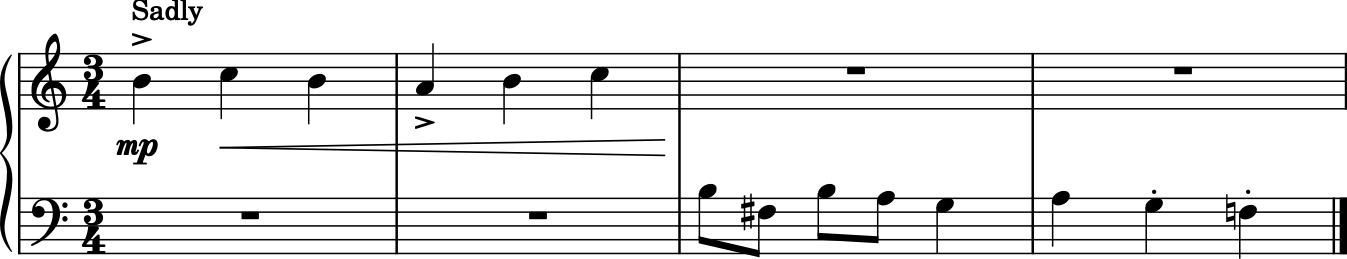

Hand pattern: ['R', 'R', 'L', 'L']
(1.5, 0.5, 0.5, 0.5, 0.5, 0.5) 2
(1.0, 0.5, 0.5, 0.5, 0.5, 1.0) 1
(0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 1.0) 44
(0.5, 0.5, 1.0, 1.0, 1.0) 1
(1.0, 1.0, 0.5, 0.5, 0.5, 0.5) 1
(1.0, 1.0, 1.0, 1.0) 2
(0.5, 0.5, 2.0, 1.0) 10
(0.5, 1.0, 0.5, 0.5, 1.0, 0.5) 27
(0.5, 0.5, 0.5, 0.5, 0.5, 1.0, 0.5) 16
(0.5, 0.5, 1.0, 0.5, 0.5, 1.0) 32
(0.5, 0.5, 1.0, 0.5, 0.5, 0.5, 0.5) 1
(0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5) 1
(0.5, 0.5, 1.0, 2.0) 36
(1.0, 1.0, 0.5, 0.5, 1.0) 7
(2.0, 2.0) 9
(0.5, 0.5, 0.5, 0.5, 1.0, 1.0) 3
(0.5, 0.5, 0.5, 0.5, 2.0) 4
(1.0, 1.0, 2.0) 1
(1.0, 1.5, 0.5, 0.5, 0.5) 1
(1.0, 0.5, 0.5, 1.0, 1.0) 9
(2.0, 1.0, 1.0) 1
(1.0, 2.0, 1.0) 80
(1.5, 0.5, 0.5, 1.5) 3
(1.0, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5) 1
(2.0, 0.5, 0.5, 1.0) 11
(1.0, 0.5, 0.5, 2.0) 14
(1.0, 0.5, 0.5, 1.0, 0.5, 0.5) 94
(2.0, 1.5, 0.5) 1
(1.0, 0.5, 0.5, 1.5, 0.5) 15
(2.0, 0.5, 0.5, 0.5, 0.5) 2
(0.5, 1.5, 0.5, 0.5, 0.5, 0.5) 7
(0.5, 0.5, 0.5, 0.5, 1.5, 0.5) 1
(1.0, 2.0, 0.5, 0.5) 2
(1.0, 1.0, 1.0, 0.5,

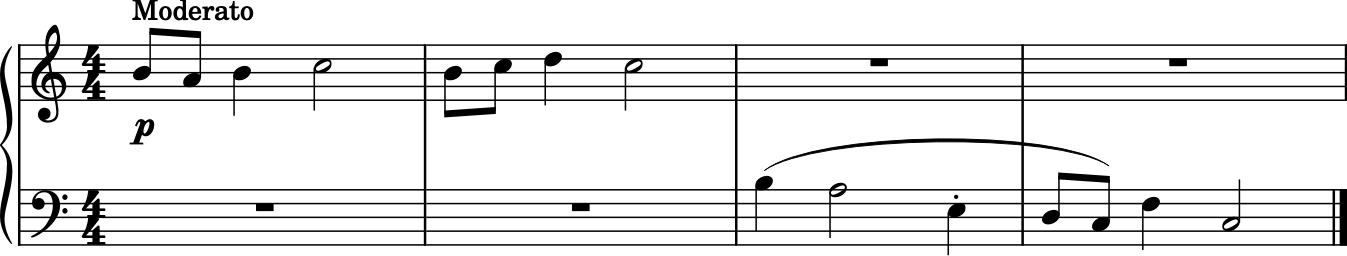

Hand pattern: ['R', 'R', 'L', 'LR']
(1.5, 0.5, 0.5, 0.5, 0.5, 0.5) 2
(1.0, 0.5, 0.5, 0.5, 0.5, 1.0) 1
(0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 1.0) 44
(0.5, 0.5, 1.0, 1.0, 1.0) 1
(1.0, 1.0, 0.5, 0.5, 0.5, 0.5) 1
(1.0, 1.0, 1.0, 1.0) 2
(0.5, 0.5, 2.0, 1.0) 10
(0.5, 1.0, 0.5, 0.5, 1.0, 0.5) 27
(0.5, 0.5, 0.5, 0.5, 0.5, 1.0, 0.5) 16
(0.5, 0.5, 1.0, 0.5, 0.5, 1.0) 32
(0.5, 0.5, 1.0, 0.5, 0.5, 0.5, 0.5) 1
(0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5) 1
(0.5, 0.5, 1.0, 2.0) 36
(1.0, 1.0, 0.5, 0.5, 1.0) 7
(2.0, 2.0) 9
(0.5, 0.5, 0.5, 0.5, 1.0, 1.0) 3
(0.5, 0.5, 0.5, 0.5, 2.0) 4
(1.0, 1.0, 2.0) 1
(1.0, 1.5, 0.5, 0.5, 0.5) 1
(1.0, 0.5, 0.5, 1.0, 1.0) 9
(2.0, 1.0, 1.0) 1
(1.0, 2.0, 1.0) 80
(1.5, 0.5, 0.5, 1.5) 3
(1.0, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5) 1
(2.0, 0.5, 0.5, 1.0) 11
(1.0, 0.5, 0.5, 2.0) 14
(1.0, 0.5, 0.5, 1.0, 0.5, 0.5) 94
(2.0, 1.5, 0.5) 1
(1.0, 0.5, 0.5, 1.5, 0.5) 15
(2.0, 0.5, 0.5, 0.5, 0.5) 2
(0.5, 1.5, 0.5, 0.5, 0.5, 0.5) 7
(0.5, 0.5, 0.5, 0.5, 1.5, 0.5) 1
(1.0, 2.0, 0.5, 0.5) 2
(1.0, 1.0, 1.0, 0.5

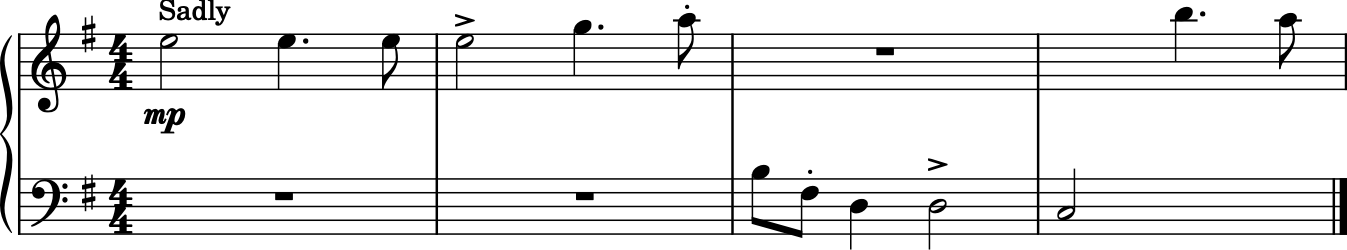

Hand pattern: ['L', 'R', 'LR', 'RL']
(1.5, 0.5, 0.5, 0.5, 0.5, 0.5) 2
(1.0, 0.5, 0.5, 0.5, 0.5, 1.0) 1
(0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 1.0) 44
(0.5, 0.5, 1.0, 1.0, 1.0) 1
(1.0, 1.0, 0.5, 0.5, 0.5, 0.5) 1
(1.0, 1.0, 1.0, 1.0) 2
(0.5, 0.5, 2.0, 1.0) 10
(0.5, 1.0, 0.5, 0.5, 1.0, 0.5) 27
(0.5, 0.5, 0.5, 0.5, 0.5, 1.0, 0.5) 16
(0.5, 0.5, 1.0, 0.5, 0.5, 1.0) 32
(0.5, 0.5, 1.0, 0.5, 0.5, 0.5, 0.5) 1
(0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5) 1
(0.5, 0.5, 1.0, 2.0) 36
(1.0, 1.0, 0.5, 0.5, 1.0) 7
(2.0, 2.0) 9
(0.5, 0.5, 0.5, 0.5, 1.0, 1.0) 3
(0.5, 0.5, 0.5, 0.5, 2.0) 4
(1.0, 1.0, 2.0) 1
(1.0, 1.5, 0.5, 0.5, 0.5) 1
(1.0, 0.5, 0.5, 1.0, 1.0) 9
(2.0, 1.0, 1.0) 1
(1.0, 2.0, 1.0) 80
(1.5, 0.5, 0.5, 1.5) 3
(1.0, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5) 1
(2.0, 0.5, 0.5, 1.0) 11
(1.0, 0.5, 0.5, 2.0) 14
(1.0, 0.5, 0.5, 1.0, 0.5, 0.5) 94
(2.0, 1.5, 0.5) 1
(1.0, 0.5, 0.5, 1.5, 0.5) 15
(2.0, 0.5, 0.5, 0.5, 0.5) 2
(0.5, 1.5, 0.5, 0.5, 0.5, 0.5) 7
(0.5, 0.5, 0.5, 0.5, 1.5, 0.5) 1
(1.0, 2.0, 0.5, 0.5) 2
(1.0, 1.0, 1.0, 0.

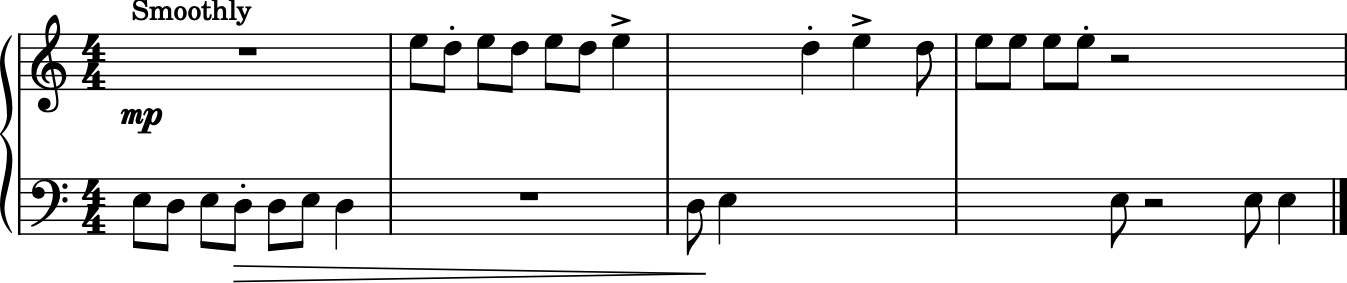

In [5]:
for i in range(5):
    exercise, params = generate_exercise(
        pitch_markov_prob,
        rhythm_dict,
        grade=1
    )

    render_exercise(exercise, params)

Hand pattern: ['R', 'R', 'R', 'L']
(0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25) 3
(0.5, 0.5, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25) 23
(1.0, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25) 2
(0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 1.0) 21
(0.5, 0.5, 0.5, 0.5, 0.5, 0.5) 2
(1.0, 1.0, 1.0) 4
(2.0, 1.0) 2
(0.5, 0.5, 0.5, 0.5, 1.0) 168
(0.5, 0.5, 1.0, 1.0) 2
(0.5, 0.5, 2.0) 6
(1.0, 0.5, 0.5, 0.5, 0.5) 7
(1.0, 2.0) 2
(1.0, 1.5, 0.5) 2
(0.5, 0.5, 1.5, 0.5) 2
(1.0, 1.0, 0.5, 0.5) 1
(0.5, 0.25, 0.25, 0.5, 0.5, 0.5, 0.5) 83
(0.25, 0.25, 0.25, 0.25, 1.0, 1.0) 30
(0.25, 0.25, 0.5, 0.5, 0.5, 0.5, 0.5) 6
(1.0, 1.0, 0.25, 0.25, 0.5) 4
(1.0, 0.5, 0.5, 1.0) 6
(1.5, 0.25, 0.25, 1.0) 10
(0.25, 0.25, 0.5, 2.0) 5
(0.5, 0.25, 0.25, 0.5, 0.25, 0.25, 1.0) 9
(0.5, 0.25, 0.25, 0.5, 0.5, 1.0) 1
(0.5, 0.25, 0.25, 1.0, 1.0) 18
(0.25, 0.25, 0.25, 0.25, 2.0) 1
(0.5, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25) 1
(0.5, 0.25, 0.25, 0.5, 0.25, 0.25, 0.25, 0.2

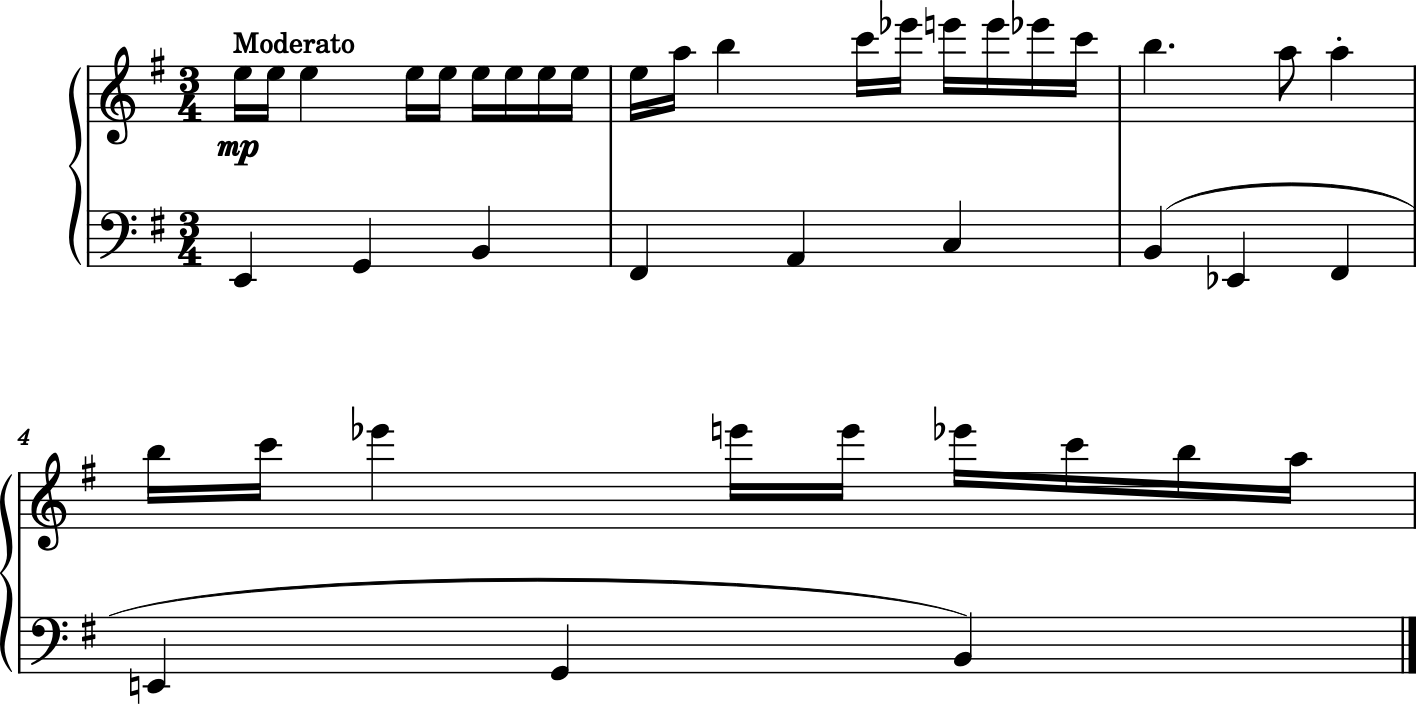

Hand pattern: ['R', 'R', 'R', 'R']
(4.0,) 4
(1.5, 0.5, 0.5, 0.5, 0.5, 0.5) 2
(1.0, 0.5, 0.5, 0.5, 0.5, 1.0) 1
(0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 1.0) 44
(0.5, 0.5, 1.0, 1.0, 1.0) 1
(1.0, 1.0, 0.5, 0.5, 0.5, 0.5) 1
(1.0, 1.0, 1.0, 1.0) 2
(1.0, 0.5, 0.5, 0.5, 0.5, 0.5, 0.25, 0.25) 1
(1.0, 1.0, 1.0, 0.5, 0.25, 0.25) 2
(1.0, 1.0, 0.25, 0.25, 0.5, 1.0) 2
(1.0, 1.0, 0.5, 0.25, 0.25, 1.0) 1
(0.5, 0.5, 2.0, 1.0) 10
(0.5, 1.0, 0.5, 0.25, 0.25, 1.5) 2
(0.5, 1.0, 0.5, 0.25, 0.25, 0.5, 0.5, 0.5) 2
(0.5, 1.0, 0.5, 0.5, 1.0, 0.5) 27
(0.5, 0.5, 0.5, 0.5, 0.5, 1.0, 0.5) 16
(0.5, 0.5, 1.0, 0.5, 0.5, 1.0) 32
(0.5, 0.5, 1.0, 0.5, 0.5, 0.5, 0.5) 1
(0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5) 1
(0.5, 0.5, 1.0, 2.0) 36
(0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25) 1
(0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.5, 0.5) 14
(0.25, 0.25, 0.25, 0.25, 0.5, 0.5, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25) 4
(0.5, 0.5, 0.5, 0.5, 0.25, 0.25

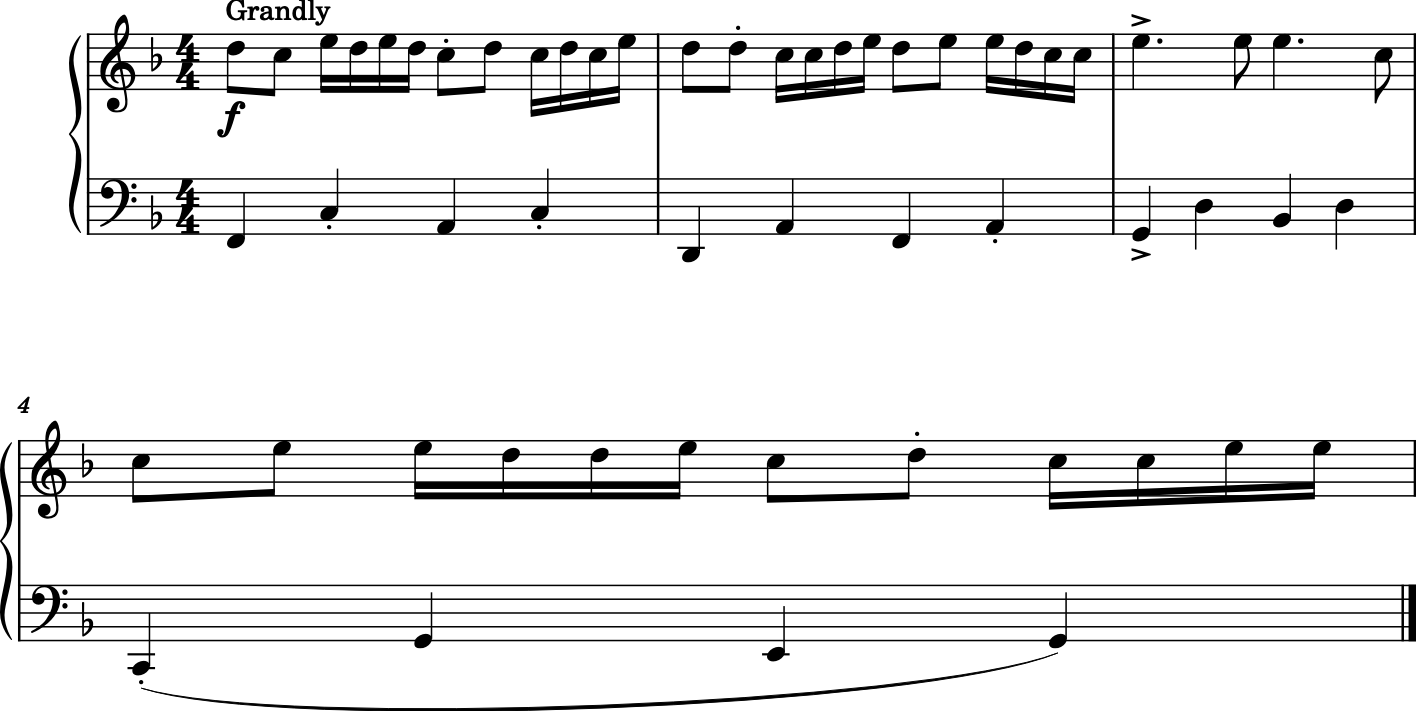

Hand pattern: ['R', 'R', 'R', 'R']
(4.0,) 4
(1.5, 0.5, 0.5, 0.5, 0.5, 0.5) 2
(1.0, 0.5, 0.5, 0.5, 0.5, 1.0) 1
(0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 1.0) 44
(0.5, 0.5, 1.0, 1.0, 1.0) 1
(1.0, 1.0, 0.5, 0.5, 0.5, 0.5) 1
(1.0, 1.0, 1.0, 1.0) 2
(1.0, 0.5, 0.5, 0.5, 0.5, 0.5, 0.25, 0.25) 1
(1.0, 1.0, 1.0, 0.5, 0.25, 0.25) 2
(1.0, 1.0, 0.25, 0.25, 0.5, 1.0) 2
(1.0, 1.0, 0.5, 0.25, 0.25, 1.0) 1
(0.5, 0.5, 2.0, 1.0) 10
(0.5, 1.0, 0.5, 0.25, 0.25, 1.5) 2
(0.5, 1.0, 0.5, 0.25, 0.25, 0.5, 0.5, 0.5) 2
(0.5, 1.0, 0.5, 0.5, 1.0, 0.5) 27
(0.5, 0.5, 0.5, 0.5, 0.5, 1.0, 0.5) 16
(0.5, 0.5, 1.0, 0.5, 0.5, 1.0) 32
(0.5, 0.5, 1.0, 0.5, 0.5, 0.5, 0.5) 1
(0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5) 1
(0.5, 0.5, 1.0, 2.0) 36
(0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25) 1
(0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.5, 0.5) 14
(0.25, 0.25, 0.25, 0.25, 0.5, 0.5, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25) 4
(0.5, 0.5, 0.5, 0.5, 0.25, 0.25

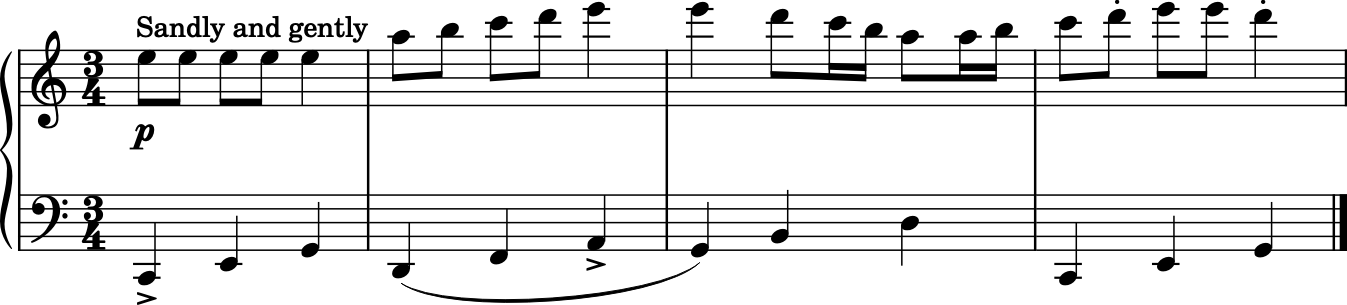

Hand pattern: ['L', 'L', 'R', 'R']
(4.0,) 4
(1.5, 0.5, 0.5, 0.5, 0.5, 0.5) 2
(1.0, 0.5, 0.5, 0.5, 0.5, 1.0) 1
(0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 1.0) 44
(0.5, 0.5, 1.0, 1.0, 1.0) 1
(1.0, 1.0, 0.5, 0.5, 0.5, 0.5) 1
(1.0, 1.0, 1.0, 1.0) 2
(1.0, 0.5, 0.5, 0.5, 0.5, 0.5, 0.25, 0.25) 1
(1.0, 1.0, 1.0, 0.5, 0.25, 0.25) 2
(1.0, 1.0, 0.25, 0.25, 0.5, 1.0) 2
(1.0, 1.0, 0.5, 0.25, 0.25, 1.0) 1
(0.5, 0.5, 2.0, 1.0) 10
(0.5, 1.0, 0.5, 0.25, 0.25, 1.5) 2
(0.5, 1.0, 0.5, 0.25, 0.25, 0.5, 0.5, 0.5) 2
(0.5, 1.0, 0.5, 0.5, 1.0, 0.5) 27
(0.5, 0.5, 0.5, 0.5, 0.5, 1.0, 0.5) 16
(0.5, 0.5, 1.0, 0.5, 0.5, 1.0) 32
(0.5, 0.5, 1.0, 0.5, 0.5, 0.5, 0.5) 1
(0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5) 1
(0.5, 0.5, 1.0, 2.0) 36
(0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25) 1
(0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.5, 0.5) 14
(0.25, 0.25, 0.25, 0.25, 0.5, 0.5, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25) 4
(0.5, 0.5, 0.5, 0.5, 0.25, 0.25

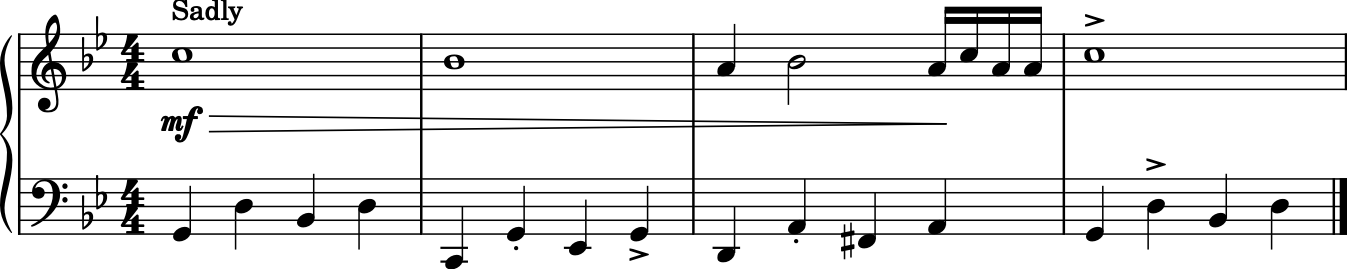

Hand pattern: ['R', 'R', 'R', 'R']
(4.0,) 4
(1.5, 0.5, 0.5, 0.5, 0.5, 0.5) 2
(1.0, 0.5, 0.5, 0.5, 0.5, 1.0) 1
(0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 1.0) 44
(0.5, 0.5, 1.0, 1.0, 1.0) 1
(1.0, 1.0, 0.5, 0.5, 0.5, 0.5) 1
(1.0, 1.0, 1.0, 1.0) 2
(1.0, 0.5, 0.5, 0.5, 0.5, 0.5, 0.25, 0.25) 1
(1.0, 1.0, 1.0, 0.5, 0.25, 0.25) 2
(1.0, 1.0, 0.25, 0.25, 0.5, 1.0) 2
(1.0, 1.0, 0.5, 0.25, 0.25, 1.0) 1
(0.5, 0.5, 2.0, 1.0) 10
(0.5, 1.0, 0.5, 0.25, 0.25, 1.5) 2
(0.5, 1.0, 0.5, 0.25, 0.25, 0.5, 0.5, 0.5) 2
(0.5, 1.0, 0.5, 0.5, 1.0, 0.5) 27
(0.5, 0.5, 0.5, 0.5, 0.5, 1.0, 0.5) 16
(0.5, 0.5, 1.0, 0.5, 0.5, 1.0) 32
(0.5, 0.5, 1.0, 0.5, 0.5, 0.5, 0.5) 1
(0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5) 1
(0.5, 0.5, 1.0, 2.0) 36
(0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25) 1
(0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.5, 0.5) 14
(0.25, 0.25, 0.25, 0.25, 0.5, 0.5, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25) 4
(0.5, 0.5, 0.5, 0.5, 0.25, 0.25

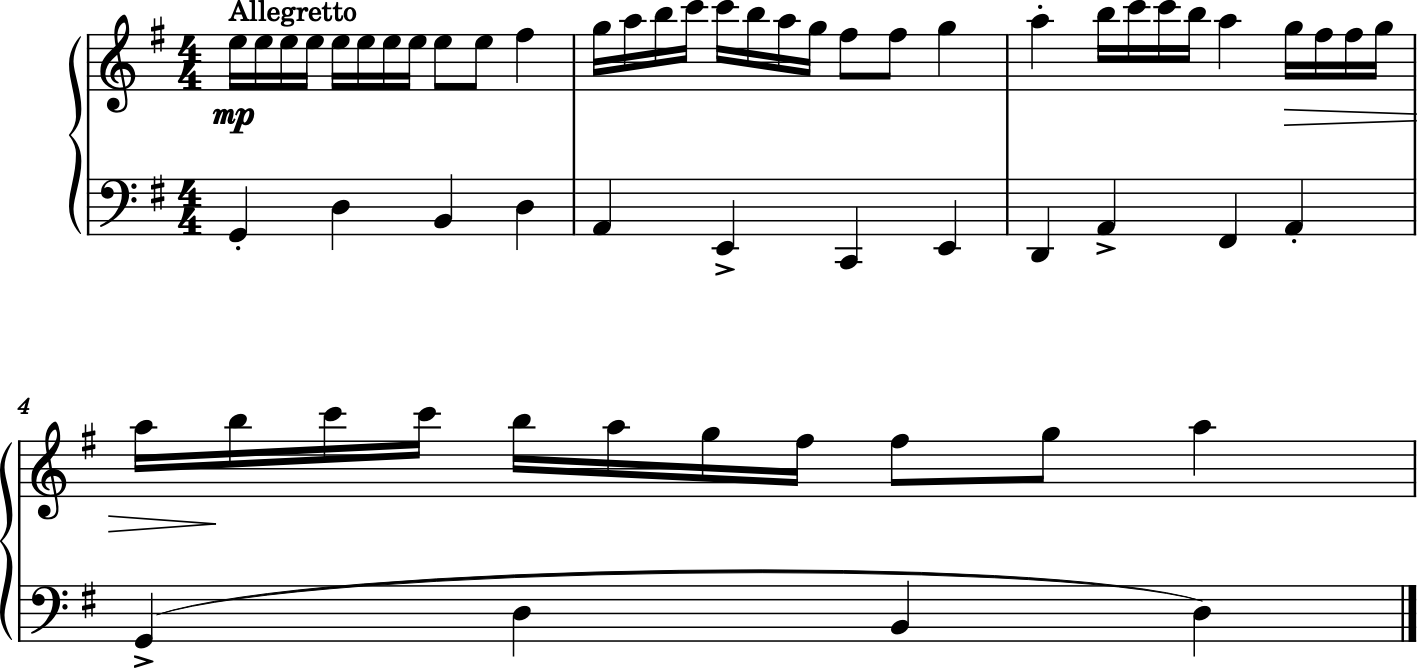

In [7]:
for i in range(5):
    exercise, params = generate_exercise(
        pitch_markov_prob,
        rhythm_dict,
        grade=2
    )

    render_exercise(exercise, params)

Hand pattern: ['L', 'L', 'RL', 'R']
(0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25) 3
(0.5, 0.5, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25) 23
(1.0, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25) 2
(0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 1.0) 21
(0.5, 0.5, 0.5, 0.5, 0.5, 0.5) 2
(1.0, 0.5, 0.25, 0.25, 0.75, 0.25) 2
(1.5, 0.25, 0.25, 0.75, 0.25) 22
(0.75, 0.25, 1.0, 0.75, 0.25) 2
(3.0,) 2
(1.0, 1.0, 1.0) 4
(2.0, 1.0) 2
(0.5, 0.5, 0.5, 0.5, 1.0) 168
(0.5, 0.5, 1.0, 1.0) 2
(0.5, 0.5, 2.0) 6
(1.0, 0.5, 0.5, 0.5, 0.5) 7
(1.0, 2.0) 2
(1.0, 1.5, 0.5) 2
(0.5, 0.5, 1.5, 0.5) 2
(1.0, 1.0, 0.5, 0.5) 1
(0.5, 0.25, 0.25, 0.5, 0.5, 0.5, 0.5) 83
(0.25, 0.25, 0.25, 0.25, 1.0, 1.0) 30
(1.0, 0.75, 0.25, 1.0) 1
(0.25, 0.25, 0.5, 0.5, 0.5, 0.5, 0.5) 6
(1.0, 1.0, 0.25, 0.25, 0.5) 4
(1.0, 0.5, 0.5, 1.0) 6
(1.5, 0.25, 0.25, 1.0) 10
(0.25, 0.25, 0.5, 2.0) 5
(0.5, 0.25, 0.25, 0.5, 0.25, 0.25, 1.0) 9
(0.5, 0.25, 0.25, 0.5, 0.5, 1.0) 1
(0.5, 0.25, 0.25, 1.0, 1.0) 18
(0.25, 

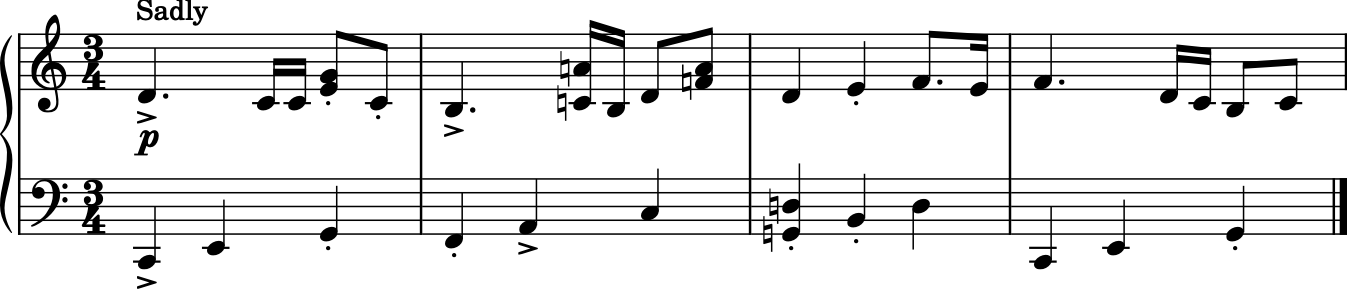

Hand pattern: ['L', 'R', 'RL', 'R']
(0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25) 3
(0.5, 0.5, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25) 23
(1.0, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25) 2
(0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 1.0) 21
(0.5, 0.5, 0.5, 0.5, 0.5, 0.5) 2
(1.0, 0.5, 0.25, 0.25, 0.75, 0.25) 2
(1.5, 0.25, 0.25, 0.75, 0.25) 22
(0.75, 0.25, 1.0, 0.75, 0.25) 2
(3.0,) 2
(1.0, 1.0, 1.0) 4
(2.0, 1.0) 2
(0.5, 0.5, 0.5, 0.5, 1.0) 168
(0.5, 0.5, 1.0, 1.0) 2
(0.5, 0.5, 2.0) 6
(1.0, 0.5, 0.5, 0.5, 0.5) 7
(1.0, 2.0) 2
(1.0, 1.5, 0.5) 2
(0.5, 0.5, 1.5, 0.5) 2
(1.0, 1.0, 0.5, 0.5) 1
(0.5, 0.25, 0.25, 0.5, 0.5, 0.5, 0.5) 83
(0.25, 0.25, 0.25, 0.25, 1.0, 1.0) 30
(1.0, 0.75, 0.25, 1.0) 1
(0.25, 0.25, 0.5, 0.5, 0.5, 0.5, 0.5) 6
(1.0, 1.0, 0.25, 0.25, 0.5) 4
(1.0, 0.5, 0.5, 1.0) 6
(1.5, 0.25, 0.25, 1.0) 10
(0.25, 0.25, 0.5, 2.0) 5
(0.5, 0.25, 0.25, 0.5, 0.25, 0.25, 1.0) 9
(0.5, 0.25, 0.25, 0.5, 0.5, 1.0) 1
(0.5, 0.25, 0.25, 1.0, 1.0) 18
(0.25, 

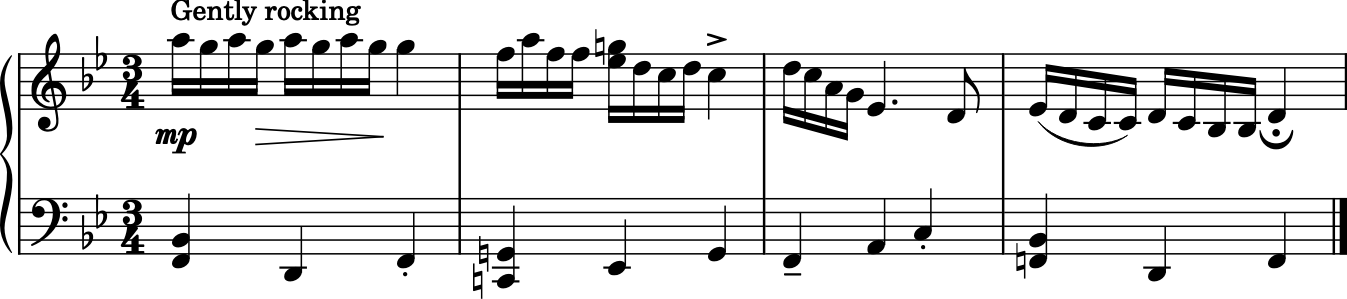

Hand pattern: ['R', 'R', 'RL', 'L', 'RL', 'LR']
(2.0,) 13
(0.5, 0.5, 0.5, 0.5) 1
(0.5, 1.5) 27
(0.5, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25) 20
(0.25, 0.25, 0.25, 0.25, 0.25, 0.75) 9
(0.25, 0.75, 1.0) 9
(0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25) 4
(0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.5) 2
(1.5, 0.25, 0.25) 4
(0.5, 0.5, 0.25, 0.25, 0.25, 0.25) 6
(1.0, 0.5, 0.25, 0.25) 1
(0.5, 0.5, 0.5, 0.25, 0.25) 1
(0.25, 0.25, 0.25, 0.25, 0.5, 0.25, 0.25) 25
(1.0, 0.5, 0.5) 1
(0.5, 1.0, 0.5) 2
(1.0, 1.0) 2
(0.5, 0.5, 1.0) 3
(0.25, 0.25, 0.5, 0.25, 0.75) 6
(0.25, 0.25, 0.5, 0.25, 0.25, 0.5) 1
(1.0, 0.25, 0.25, 0.25, 0.25) 1
(0.5, 0.25, 0.25, 0.5, 0.5) 1
(0.5, 0.25, 0.25, 0.5, 0.25, 0.25) 1
(1.5, 0.5) 1
(1.0, 0.75, 0.25) 2
(0.75, 0.25, 0.75, 0.25) 52
(0.25, 0.5, 0.25, 0.25, 0.5, 0.25) 5
(0.5, 0.5, 0.75, 0.25) 4
(0.25, 0.25, 0.25, 0.25, 1.0) 85
(0.25, 0.25, 1.0, 0.5) 34
(0.25, 0.25, 0.75, 0.25, 0.25, 0.25) 5
(0.25, 0.25, 1.5) 13
(0.75, 0.25, 0.25, 0.25, 0.5) 2
(0.5, 1.0, 0.25, 0.25) 3
(0.25, 0.25, 0.

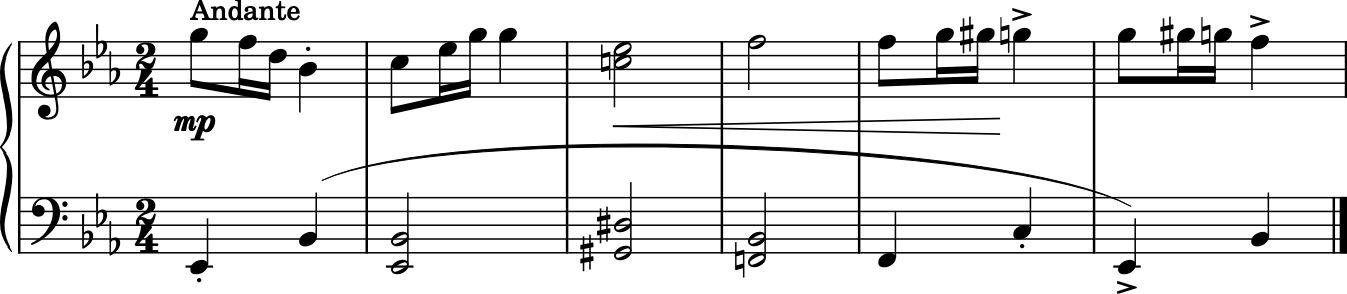

Hand pattern: ['RL', 'RL', 'R', 'BOTH']
(0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25) 3
(0.5, 0.5, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25) 23
(1.0, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25) 2
(0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 1.0) 21
(0.5, 0.5, 0.5, 0.5, 0.5, 0.5) 2
(1.0, 0.5, 0.25, 0.25, 0.75, 0.25) 2
(1.5, 0.25, 0.25, 0.75, 0.25) 22
(0.75, 0.25, 1.0, 0.75, 0.25) 2
(3.0,) 2
(1.0, 1.0, 1.0) 4
(2.0, 1.0) 2
(0.5, 0.5, 0.5, 0.5, 1.0) 168
(0.5, 0.5, 1.0, 1.0) 2
(0.5, 0.5, 2.0) 6
(1.0, 0.5, 0.5, 0.5, 0.5) 7
(1.0, 2.0) 2
(1.0, 1.5, 0.5) 2
(0.5, 0.5, 1.5, 0.5) 2
(1.0, 1.0, 0.5, 0.5) 1
(0.5, 0.25, 0.25, 0.5, 0.5, 0.5, 0.5) 83
(0.25, 0.25, 0.25, 0.25, 1.0, 1.0) 30
(1.0, 0.75, 0.25, 1.0) 1
(0.25, 0.25, 0.5, 0.5, 0.5, 0.5, 0.5) 6
(1.0, 1.0, 0.25, 0.25, 0.5) 4
(1.0, 0.5, 0.5, 1.0) 6
(1.5, 0.25, 0.25, 1.0) 10
(0.25, 0.25, 0.5, 2.0) 5
(0.5, 0.25, 0.25, 0.5, 0.25, 0.25, 1.0) 9
(0.5, 0.25, 0.25, 0.5, 0.5, 1.0) 1
(0.5, 0.25, 0.25, 1.0, 1.0) 18
(0.

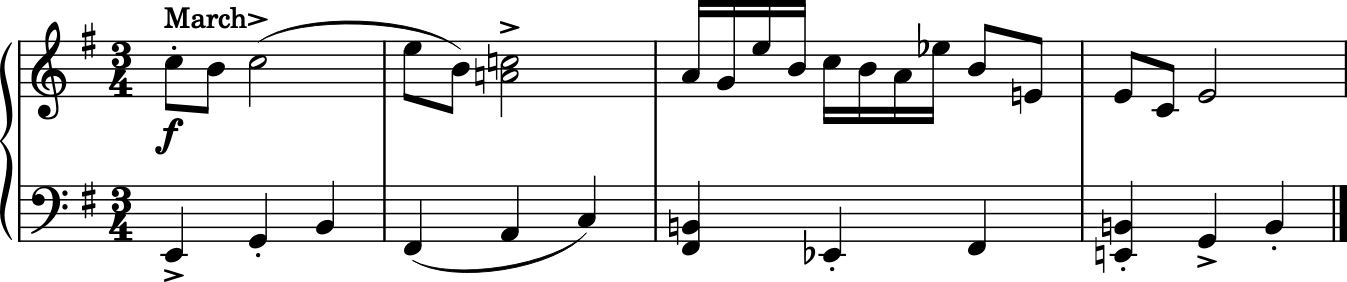

Hand pattern: ['LR', 'LR', 'R', 'L', 'BOTH', 'L', 'L', 'LR']
(0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25) 3
(0.5, 0.5, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25) 23
(1.0, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25) 2
(0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 1.0) 21
(0.5, 0.5, 0.5, 0.5, 0.5, 0.5) 2
(1.0, 0.5, 0.25, 0.25, 0.75, 0.25) 2
(1.5, 0.25, 0.25, 0.75, 0.25) 22
(0.75, 0.25, 1.0, 0.75, 0.25) 2
(3.0,) 2
(1.0, 1.0, 1.0) 4
(2.0, 1.0) 2
(0.5, 0.5, 0.5, 0.5, 1.0) 168
(0.5, 0.5, 1.0, 1.0) 2
(0.5, 0.5, 2.0) 6
(1.0, 0.5, 0.5, 0.5, 0.5) 7
(1.0, 2.0) 2
(1.0, 1.5, 0.5) 2
(0.5, 0.5, 1.5, 0.5) 2
(1.0, 1.0, 0.5, 0.5) 1
(0.5, 0.25, 0.25, 0.5, 0.5, 0.5, 0.5) 83
(0.25, 0.25, 0.25, 0.25, 1.0, 1.0) 30
(1.0, 0.75, 0.25, 1.0) 1
(0.25, 0.25, 0.5, 0.5, 0.5, 0.5, 0.5) 6
(1.0, 1.0, 0.25, 0.25, 0.5) 4
(1.0, 0.5, 0.5, 1.0) 6
(1.5, 0.25, 0.25, 1.0) 10
(0.25, 0.25, 0.5, 2.0) 5
(0.5, 0.25, 0.25, 0.5, 0.25, 0.25, 1.0) 9
(0.5, 0.25, 0.25, 0.5, 0.5, 1.0) 1
(0.5, 0.25, 0

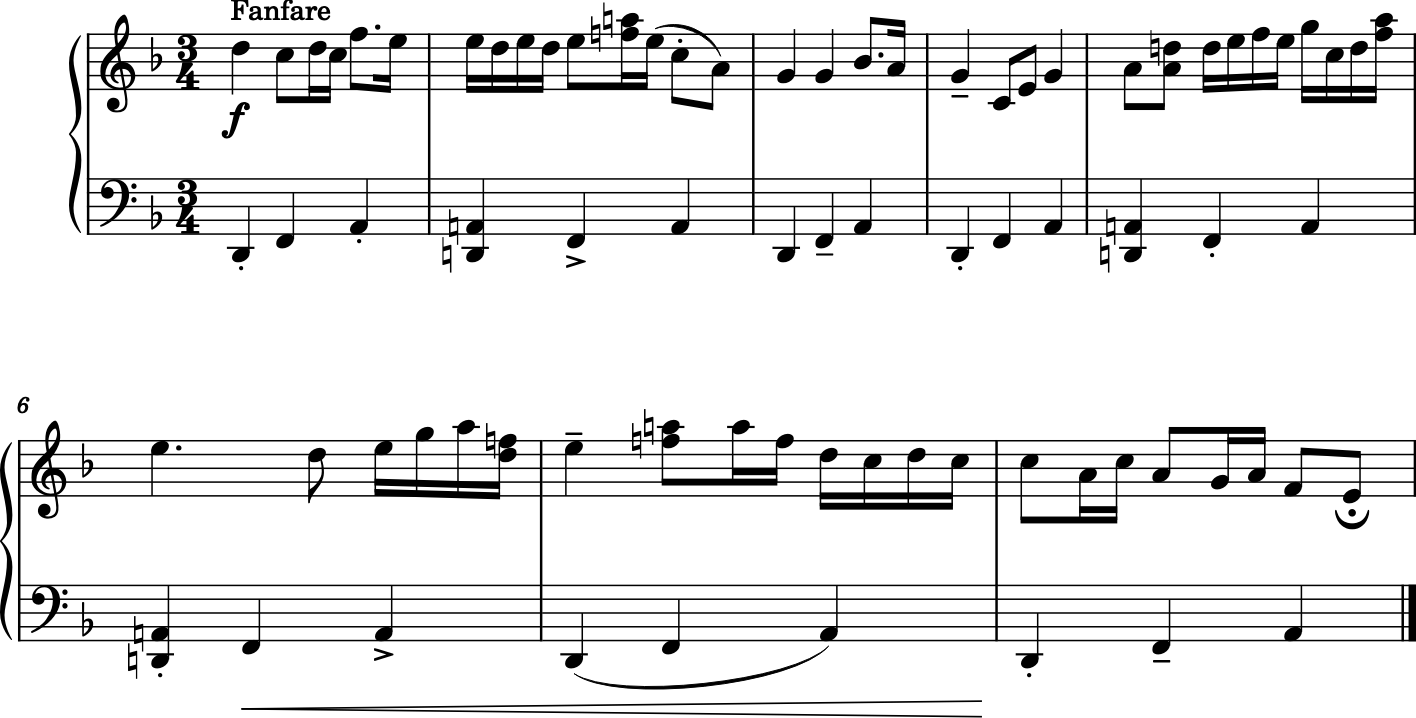

Hand pattern: ['R', 'LR', 'RL', 'BOTH', 'L', 'RL', 'LR', 'L']
(0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25) 3
(0.5, 0.5, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25) 23
(1.0, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25) 2
(0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 1.0) 21
(0.5, 0.5, 0.5, 0.5, 0.5, 0.5) 2
(1.0, 0.5, 0.25, 0.25, 0.75, 0.25) 2
(1.5, 0.25, 0.25, 0.75, 0.25) 22
(0.75, 0.25, 1.0, 0.75, 0.25) 2
(3.0,) 2
(1.0, 1.0, 1.0) 4
(2.0, 1.0) 2
(0.5, 0.5, 0.5, 0.5, 1.0) 168
(0.5, 0.5, 1.0, 1.0) 2
(0.5, 0.5, 2.0) 6
(1.0, 0.5, 0.5, 0.5, 0.5) 7
(1.0, 2.0) 2
(1.0, 1.5, 0.5) 2
(0.5, 0.5, 1.5, 0.5) 2
(1.0, 1.0, 0.5, 0.5) 1
(0.5, 0.25, 0.25, 0.5, 0.5, 0.5, 0.5) 83
(0.25, 0.25, 0.25, 0.25, 1.0, 1.0) 30
(1.0, 0.75, 0.25, 1.0) 1
(0.25, 0.25, 0.5, 0.5, 0.5, 0.5, 0.5) 6
(1.0, 1.0, 0.25, 0.25, 0.5) 4
(1.0, 0.5, 0.5, 1.0) 6
(1.5, 0.25, 0.25, 1.0) 10
(0.25, 0.25, 0.5, 2.0) 5
(0.5, 0.25, 0.25, 0.5, 0.25, 0.25, 1.0) 9
(0.5, 0.25, 0.25, 0.5, 0.5, 1.0) 1
(0.5, 0.25, 

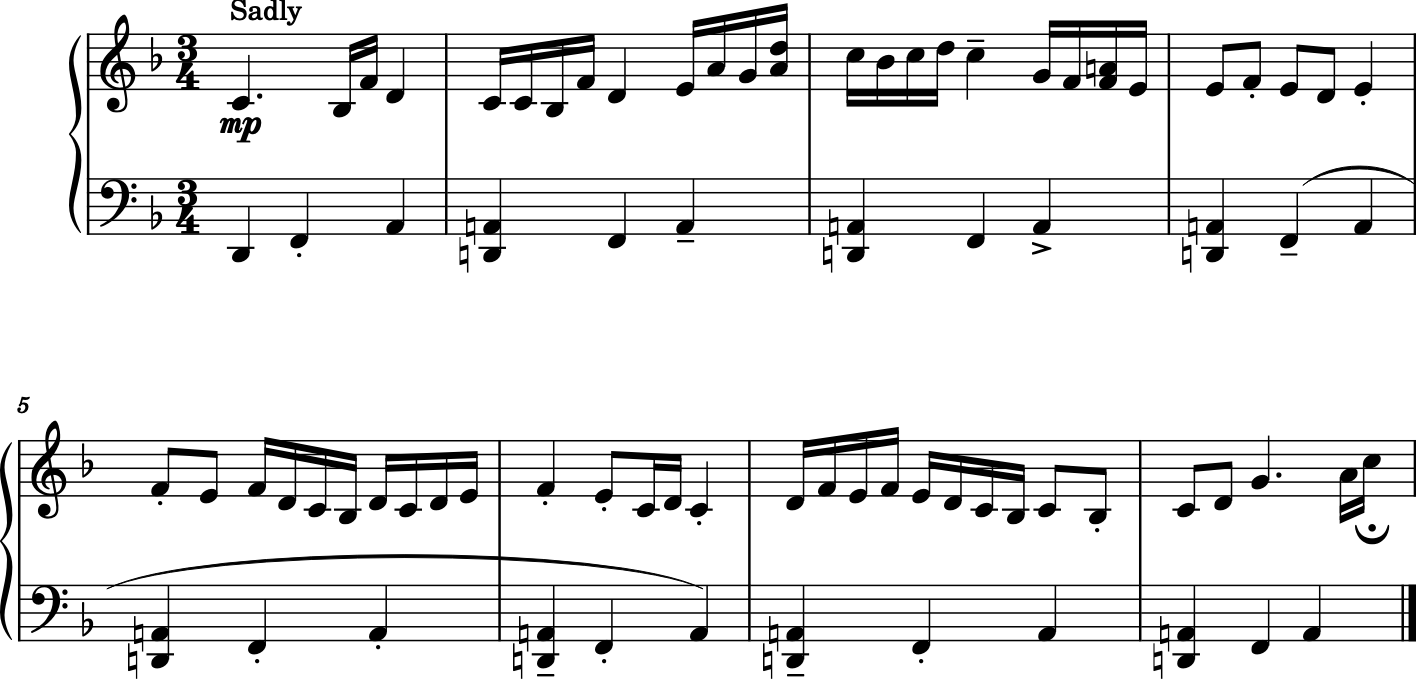

Hand pattern: ['L', 'L', 'R', 'R', 'R', 'R']
(2.0,) 13
(0.5, 0.5, 0.5, 0.5) 1
(0.5, 1.5) 27
(0.5, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25) 20
(0.25, 0.25, 0.25, 0.25, 0.25, 0.75) 9
(0.25, 0.75, 1.0) 9
(0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25) 4
(0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.5) 2
(1.5, 0.25, 0.25) 4
(0.5, 0.5, 0.25, 0.25, 0.25, 0.25) 6
(1.0, 0.5, 0.25, 0.25) 1
(0.5, 0.5, 0.5, 0.25, 0.25) 1
(0.25, 0.25, 0.25, 0.25, 0.5, 0.25, 0.25) 25
(1.0, 0.5, 0.5) 1
(0.5, 1.0, 0.5) 2
(1.0, 1.0) 2
(0.5, 0.5, 1.0) 3
(0.25, 0.25, 0.5, 0.25, 0.75) 6
(0.25, 0.25, 0.5, 0.25, 0.25, 0.5) 1
(1.0, 0.25, 0.25, 0.25, 0.25) 1
(0.5, 0.25, 0.25, 0.5, 0.5) 1
(0.5, 0.25, 0.25, 0.5, 0.25, 0.25) 1
(1.5, 0.5) 1
(1.0, 0.75, 0.25) 2
(0.75, 0.25, 0.75, 0.25) 52
(0.25, 0.5, 0.25, 0.25, 0.5, 0.25) 5
(0.5, 0.5, 0.75, 0.25) 4
(0.25, 0.25, 0.25, 0.25, 1.0) 85
(0.25, 0.25, 1.0, 0.5) 34
(0.25, 0.25, 0.75, 0.25, 0.25, 0.25) 5
(0.25, 0.25, 1.5) 13
(0.75, 0.25, 0.25, 0.25, 0.5) 2
(0.5, 1.0, 0.25, 0.25) 3
(0.25, 0.25, 0.25,

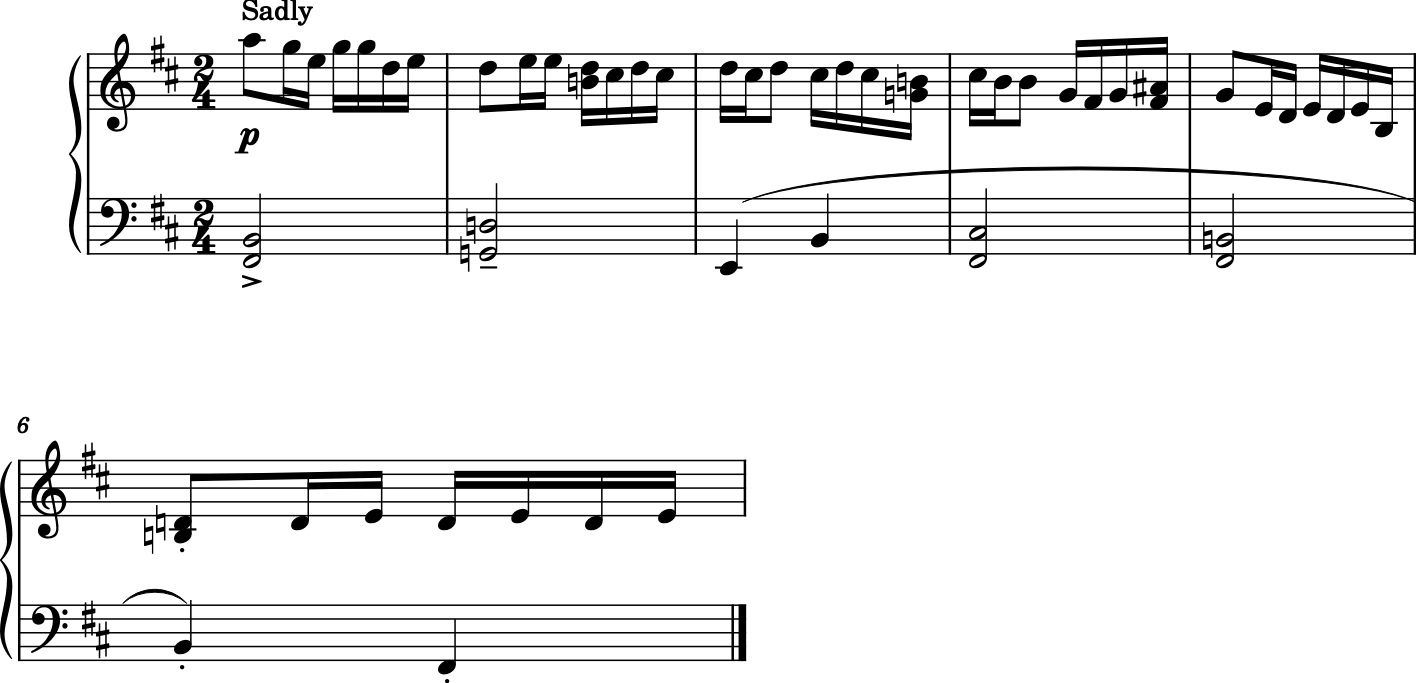

Hand pattern: ['LR', 'R', 'LR', 'BOTH']
(0.25, 0.25, 0.25, 0.25, 0.25, 0.25) 1
(0.5, 1.0) 1
(1.5,) 1
(0.25, 0.25, 1.0) 15
(0.25, 0.25, 0.25, 0.25, 0.5) 2
(0.5, 0.25, 0.25, 0.25, 0.25) 7
(0.5, 0.5, 0.5) 2
(1.0, 0.25, 0.25) 8
(1.0, 0.5) 13
(0.25, 0.5, 0.25, 0.25, 0.25) 6
(0.5, 0.5, 0.25, 0.25) 9
(0.75, 0.25, 0.25, 0.25) 34
(0.25, 0.25, 0.25, 0.5, 0.25) 3
(0.25, 0.25, 0.5, 0.5) 4
(0.5, 0.25, 0.25, 0.5) 42
(0.75, 0.25, 0.5) 20
(0.25, 0.25, 0.75, 0.25) 40
(0.25, 0.25, 0.5, 0.25, 0.25) 4
(0.5, 0.75, 0.25) 1
(0.25, 0.5, 0.5, 0.25) 14
rhythm_plan: [(0.5, 0.5, 0.25, 0.25), (0.5, 0.5, 0.25, 0.25), (0.75, 0.25, 0.25, 0.25), (0.5, 0.5, 0.25, 0.25)]
generate_exercise: position_notes:[78, 79, 81, 83, 84, 86, 88]
generate_exercise: allowed_notes:[59, 60, 62, 64, 66, 67, 69, 71, 72, 74, 76, 78, 79, 81]
generate_harmonic_plan: degree_plan: [1, 4, 5, 1]
generate_exercise: harmonic_plan: [[55, 59, 62], [48, 52, 55], [50, 54, 57], [55, 59, 62]]
bar 1, attemt number 0
constrained_transitions: max_interval 

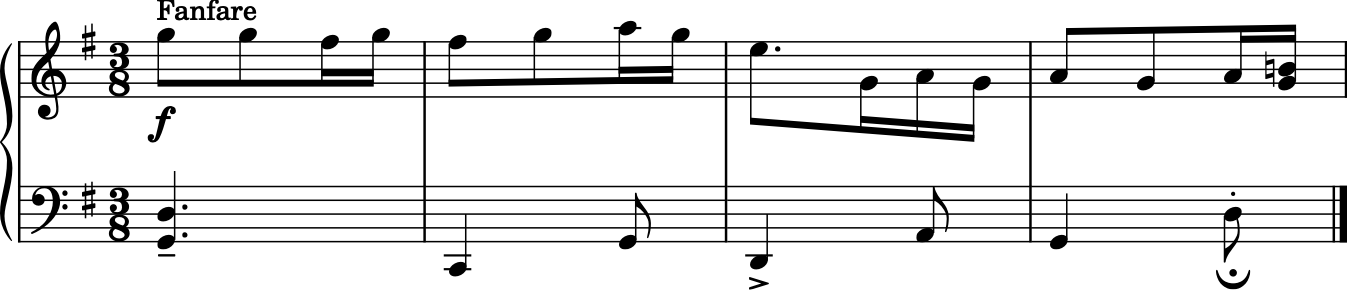

Hand pattern: ['BOTH', 'LR', 'BOTH', 'LR']
(0.25, 0.25, 0.25, 0.25, 0.25, 0.25) 1
(0.5, 1.0) 1
(1.5,) 1
(0.25, 0.25, 1.0) 15
(0.25, 0.25, 0.25, 0.25, 0.5) 2
(0.5, 0.25, 0.25, 0.25, 0.25) 7
(0.5, 0.5, 0.5) 2
(1.0, 0.25, 0.25) 8
(1.0, 0.5) 13
(0.25, 0.5, 0.25, 0.25, 0.25) 6
(0.5, 0.5, 0.25, 0.25) 9
(0.75, 0.25, 0.25, 0.25) 34
(0.25, 0.25, 0.25, 0.5, 0.25) 3
(0.25, 0.25, 0.5, 0.5) 4
(0.5, 0.25, 0.25, 0.5) 42
(0.75, 0.25, 0.5) 20
(0.25, 0.25, 0.75, 0.25) 40
(0.25, 0.25, 0.5, 0.25, 0.25) 4
(0.5, 0.75, 0.25) 1
(0.25, 0.5, 0.5, 0.25) 14
rhythm_plan: [(0.25, 0.25, 0.5, 0.25, 0.25), (0.25, 0.25, 0.5, 0.25, 0.25), (0.5, 0.25, 0.25, 0.25, 0.25), (0.25, 0.25, 0.5, 0.25, 0.25)]
generate_exercise: position_notes:[65, 67, 69, 71, 72, 74, 76]
generate_exercise: allowed_notes:[59, 60, 62, 64, 65, 67, 69, 71, 72, 74, 76, 77, 79, 81]
generate_harmonic_plan: degree_plan: [1, 2, 5, 1]
generate_exercise: harmonic_plan: [[57, 48, 52], [59, 50, 53], [52, 55, 59], [57, 48, 52]]
bar 1, attemt number 0
constrain

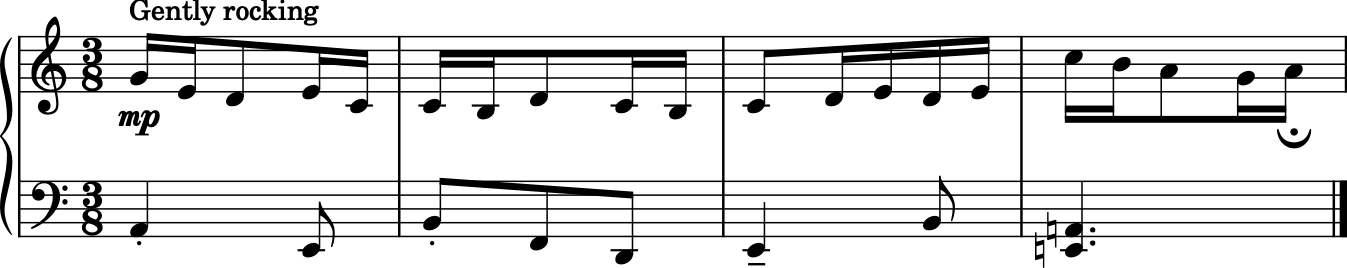

Hand pattern: ['L', 'LR', 'LR', 'RL', 'LR', 'RL']
(2.0,) 13
(0.5, 0.5, 0.5, 0.5) 1
(0.5, 1.5) 27
(0.5, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25) 20
(0.25, 0.25, 0.25, 0.25, 0.25, 0.75) 9
(0.25, 0.75, 1.0) 9
(0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25) 4
(0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.5) 2
(1.5, 0.25, 0.25) 4
(0.5, 0.5, 0.25, 0.25, 0.25, 0.25) 6
(1.0, 0.5, 0.25, 0.25) 1
(0.5, 0.5, 0.5, 0.25, 0.25) 1
(0.25, 0.25, 0.25, 0.25, 0.5, 0.25, 0.25) 25
(1.0, 0.5, 0.5) 1
(0.5, 1.0, 0.5) 2
(1.0, 1.0) 2
(0.5, 0.5, 1.0) 3
(0.25, 0.25, 0.5, 0.25, 0.75) 6
(0.25, 0.25, 0.5, 0.25, 0.25, 0.5) 1
(1.0, 0.25, 0.25, 0.25, 0.25) 1
(0.5, 0.25, 0.25, 0.5, 0.5) 1
(0.5, 0.25, 0.25, 0.5, 0.25, 0.25) 1
(1.5, 0.5) 1
(1.0, 0.75, 0.25) 2
(0.75, 0.25, 0.75, 0.25) 52
(0.25, 0.5, 0.25, 0.25, 0.5, 0.25) 5
(0.5, 0.5, 0.75, 0.25) 4
(0.25, 0.25, 0.25, 0.25, 1.0) 85
(0.25, 0.25, 1.0, 0.5) 34
(0.25, 0.25, 0.75, 0.25, 0.25, 0.25) 5
(0.25, 0.25, 1.5) 13
(0.75, 0.25, 0.25, 0.25, 0.5) 2
(0.5, 1.0, 0.25, 0.25) 3
(0.25, 0.25, 

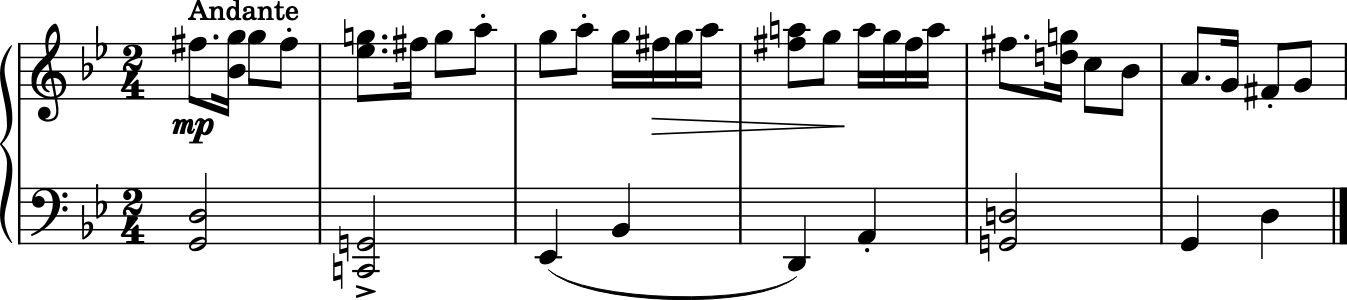

In [27]:
for i in range(10):
    exercise, params = generate_exercise(
        pitch_markov_prob,
        rhythm_dict,
        grade=4
    )

  
    render_exercise(exercise, params)